<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/07_AED_artefatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB07 — Análise Exploratória dos Artefatos do Pipeline

## 1. Contexto

Este notebook realiza a Análise Exploratória de Dados (AED) sobre os artefatos produzidos pelos notebooks NB01 a NB06 do pipeline PPCOMP_DM.

Diferentemente do NB00, que caracteriza diretamente o dataset bruto BORG/Kaggle a partir do arquivo `borg_traces_data.csv`, o NB07 não lê o CSV bruto diretamente. Sua função é analisar os artefatos já produzidos pelo pipeline, após validação, normalização temporal, agregação em janelas de 5 minutos, detecção de criticidade, engenharia de atributos e rotulagem de estados.

A separação entre NB00 e NB07 é uma decisão metodológica importante:

- o NB00 responde: "Como é o dataset bruto BORG/Kaggle antes do pipeline?";
- o NB07 responde: "O que os notebooks NB01 a NB06 produziram e quais achados exploratórios emergem dos artefatos processados?".

Com isso, o NB07 funciona como uma etapa intermediária de auditoria exploratória entre a preparação dos dados e a modelagem supervisionada posterior.

## 2. Objetivo

O objetivo deste notebook é consolidar a AED dos artefatos intermediários do pipeline, verificando a coerência estrutural e estatística dos dados que serão utilizados nas etapas posteriores de modelagem.

Especificamente, este notebook busca:

1. Verificar a integridade estrutural dos artefatos NB01 a NB06, incluindo número de linhas, número de colunas, tipos de dados e valores ausentes;
2. Comparar os artefatos iniciais do pipeline com os valores de referência documentados no NB00;
3. Avaliar o efeito do NB02 sobre a normalização temporal e sobre a preservação do bloco inicial `hour == 0`;
4. Analisar a série contínua de janelas de 5 minutos produzida pelo NB03;
5. Diferenciar lacunas estruturais de buckets ausentes e janelas vazias sem eventos;
6. Avaliar os critérios de criticidade produzidos pelo NB04, especialmente `fail_rate`, `is_critical`, limiar `µ + 2σ` e episódios detectados;
7. Registrar a leitura correta do resumo `04_detect_episodes_summary.json`, utilizando o objeto `official_result` como fonte dos valores oficiais de criticidade;
8. Avaliar análises de sensibilidade do NB04, incluindo limiar calculado apenas sobre treino e diagnóstico sem o bucket 0;
9. Caracterizar as features produzidas pelo NB05, incluindo lags, estatísticas móveis, variação percentual, z-score expansivo e demais variáveis preditoras;
10. Avaliar a distribuição dos estados operacionais produzidos pelo NB06;
11. Avaliar o dataset supervisionado `anticipation_supervised_dataset.parquet`, com foco no cenário `primary_K24_H12`;
12. Quantificar o desbalanceamento da variável `transition_target`;
13. Construir o fluxo de linhas NB00 → NB06;
14. Gerar figuras exploratórias e o resumo consolidado `07_aed_pipeline_summary.json`.

## 3. Papel no Pipeline

O NB07 é um notebook descritivo e avaliativo.

Ele não realiza limpeza adicional, não altera os artefatos do pipeline, não rotula novos estados, não treina modelos e não produz artefatos que substituam os notebooks anteriores.

Seu papel é documentar o estado dos dados ao final do pipeline de preparação e antes da modelagem. Assim, ele contribui para:

1. A rastreabilidade entre o dado bruto e a base supervisionada;
2. A identificação de possíveis inconsistências entre summaries JSON e arquivos Parquet;
3. A validação da coerência entre janelas críticas, episódios e estados operacionais;
4. A compreensão do desbalanceamento da formulação supervisionada;
5. A preparação da narrativa metodológica da dissertação;
6. A sustentação das decisões experimentais dos notebooks de modelagem.

## 4. Artefatos Utilizados

Este notebook utiliza apenas artefatos produzidos por notebooks anteriores do pipeline ou summaries de referência. Ele não lê diretamente o CSV bruto `borg_traces_data.csv`.

| Artefato | Origem | Diretório base | Finalidade |
|---|---|---|---|
| `00_aed_raw_summary.json` | NB00 | `REPORTS_PATH` | Referência estrutural do dado bruto |
| `00_aed_summary.json` | NB00 | `REPORTS_PATH` | Referência exploratória consolidada do NB00, quando disponível |
| `trace_raw_validated.parquet` | NB01 | `PROCESSED_PATH` | Dataset validado e tipado |
| `01_ingest_validate_summary.json` | NB01 | `REPORTS_PATH` | Resumo da validação inicial |
| `google_trace_clean.parquet` | NB02 | `PROCESSED_PATH` | Dataset limpo e normalizado temporalmente |
| `02_clean_normalize_summary.json` | NB02 | `REPORTS_PATH` | Resumo da normalização temporal |
| `window_5min_series.parquet` | NB03 | `FEATURES_PATH` | Série contínua em janelas de 5 minutos |
| `window_5min_base.parquet` | NB03 | `FEATURES_PATH` | Base agregada com buckets observados |
| `03_window_5min_base_summary.json` | NB03 | `REPORTS_PATH` | Resumo da agregação temporal |
| `window_5min_series_scored.parquet` | NB04 | `FEATURES_PATH` | Série com `fail_rate` e `is_critical` |
| `episodes_detected.parquet` | NB04 | `FEATURES_PATH` | Episódios críticos detectados |
| `04_detect_episodes_summary.json` | NB04 | `REPORTS_PATH` | Resumo oficial da detecção de criticidade e episódios |
| `window_5min_features.parquet` | NB05 | `FEATURES_PATH` | Série com features engenheiradas |
| `05_feature_engineering_summary.json` | NB05 | `REPORTS_PATH` | Resumo da engenharia de atributos |
| `window_5min_labeled.parquet` | NB06 | `FEATURES_PATH` | Série rotulada com estados operacionais |
| `anticipation_supervised_dataset.parquet` | NB06 | `FEATURES_PATH` | Dataset supervisionado para antecipação |
| `06_labeling_states_summary.json` | NB06 | `REPORTS_PATH` | Resumo da rotulagem de estados |

## 5. Estrutura do Notebook

O notebook está organizado em uma única célula consolidada de código, dividida internamente em blocos numerados.

A célula consolidada realiza:

1. Bootstrap, imports, configuração de paths e funções auxiliares;
2. Leitura das referências do NB00;
3. AED dos artefatos NB01 e NB02, incluindo validação estrutural, missingness, comparação com NB00 e tratamento do bloco `hour == 0`;
4. AED do NB03, com análise da série contínua de janelas de 5 minutos, cobertura de buckets, janelas vazias e comportamento do bucket inicial;
5. AED do NB04, com análise da taxa de falha, limiar `µ + 2σ`, janelas críticas, episódios detectados e diagnósticos de sensibilidade;
6. AED do NB05, com análise das features engenheiradas, estatísticas descritivas, distribuições, séries temporais e correlações;
7. AED do NB06, com análise dos estados operacionais, distribuição temporal dos estados, dataset supervisionado e desbalanceamento da variável `transition_target`;
8. Consolidação do fluxo de linhas NB00 → NB06;
9. Registro dos achados principais;
10. Geração das figuras exploratórias;
11. Persistência do resumo `07_aed_pipeline_summary.json`.

Embora o código esteja em uma única célula, os blocos internos preservam a separação lógica entre as etapas do pipeline.

## 6. Observações Metodológicas

Este notebook possui caráter estritamente exploratório e descritivo.

A análise do NB07 não redefine os critérios de criticidade, não altera os estados operacionais e não modifica a base supervisionada. Quando necessário, o notebook apenas valida a consistência entre os arquivos Parquet e os summaries JSON gerados pelos notebooks anteriores.

No caso do NB04, os valores oficiais de criticidade devem ser obtidos do objeto `official_result` do arquivo `04_detect_episodes_summary.json`. Esse objeto registra o cenário `global_full_series`, com os valores oficiais de `µ`, `σ`, limiar `µ + 2σ`, número de janelas críticas e episódios detectados.

A leitura correta desse JSON é essencial para evitar inconsistências entre o resumo textual do NB07 e os artefatos efetivamente carregados.

Mounted at /content/drive

===== PATHS =====
REPO_DIR       : /content/drive/MyDrive/Mestrado/PPCOMP_DM
PROCESSED_PATH : /content/drive/MyDrive/Mestrado/02-datasets/02-processed
FEATURES_PATH  : /content/drive/MyDrive/Mestrado/02-datasets/03-features
REPORTS_PATH   : /content/drive/MyDrive/Mestrado/04-reports
FIG_DIR        : /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline
[NB07_AED_PIPELINE] Referência NB00 raw carregado: /content/drive/MyDrive/Mestrado/04-reports/00_aed_raw_summary.json
[NB07_AED_PIPELINE] Referência NB00 consolidada carregado: /content/drive/MyDrive/Mestrado/04-reports/00_aed_summary.json

[NB07] Bloco 3 — Referências NB00 concluído.

NB01 — DATASET VALIDADO (trace_raw_validated.parquet)
[NB07_AED_PIPELINE] NB01 lido: 405891 linhas x 21 colunas

[Shape NB01]
(405891, 21)

[Tipos de dados NB01]


,dtype
time,int64
collection_id,Int64
scheduling_class,int64
priority,int64
instance_index,Int64
machine_id,Int64
resource_request,object
scheduler,float64
start_time,Int64
end_time,Int64



[Missingness NB01]


,missing_count,missing_pct
average_usage,405891,100.00
random_sample_usage,405891,100.00
maximum_usage,405891,100.00
cycles_per_instruction,124686,30.72
memory_accesses_per_instruction,124686,30.72
scheduler,959,0.24
resource_request,774,0.19



[Comparativo NB00 → NB01]
Linhas brutas NB00     : 405,894
Linhas validadas NB01  : 405,891
Diferença              : -3 (-0.0007%)
Retenção               : 99.9993%
[NB07_AED_PIPELINE] NB01 summary JSON carregado: /content/drive/MyDrive/Mestrado/04-reports/01_ingest_validate_summary.json

NB02 — DATASET LIMPO/NORMALIZADO (google_trace_clean.parquet)
[NB07_AED_PIPELINE] NB02 lido: 405891 linhas x 23 colunas

[Shape NB02]
(405891, 23)

[Colunas adicionadas pelo NB02 vs NB01]
['hour', 't_rel_us']

[Colunas removidas pelo NB02 vs NB01]
[]
[NB07_AED_PIPELINE] NB02 summary JSON carregado: /content/drive/MyDrive/Mestrado/04-reports/02_clean_normalize_summary.json

[Decisão sobre hour == 0 — NB02]
scenario_label   : keep_hour0
remove_hour_zero : False
rows_hour0       : 56,740
rows_out         : 405,891

[Cobertura temporal NB02]
hour range             : 0..744
volume min/max/médio   : 26 / 56,740 / 544.82


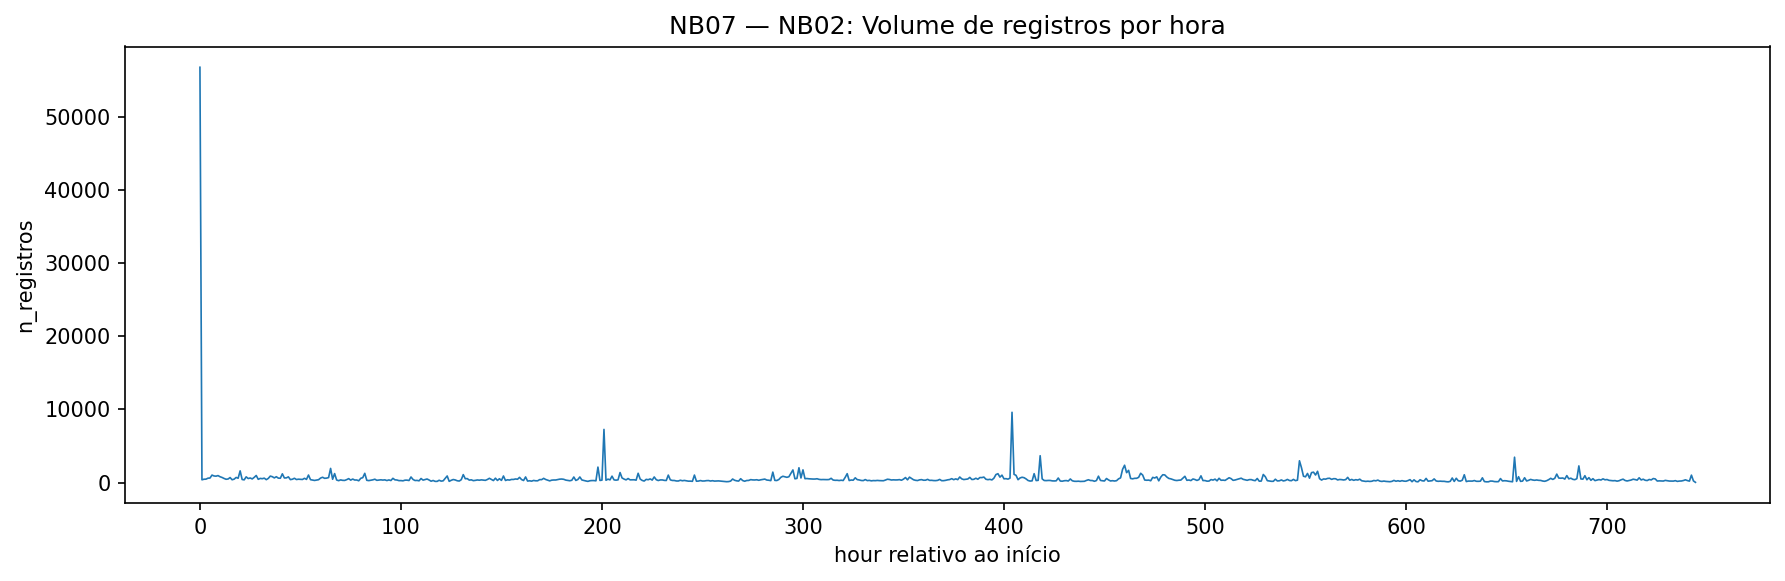

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_01_nb02_volume_por_hora.png

[NB07] Bloco 4 — AED NB01/NB02 concluída.

NB03 — SÉRIE CONTÍNUA DE JANELAS 5 MIN (window_5min_series.parquet)
[NB07_AED_PIPELINE] NB03 série lida: 8930 linhas x 18 colunas

[Shape NB03 série]
(8930, 18)

[Colunas NB03 série]
['bucket_id', 'bucket_start_us', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'mean_priority', 'mean_req_cpus', 'mean_req_mem', 'req_cpus_presence_rate', 'req_mem_presence_rate', 'event_FAIL_count', 'event_SCHEDULE_count', 'event_FINISH_count', 'event_ENABLE_count', 'event_LOST_count', 'event_EVICT_count', 'event_KILL_count']

[Amostra NB03 série]


,bucket_id,bucket_start_us,n_events,n_failed,n_machines,n_collections,mean_priority,mean_req_cpus,mean_req_mem,req_cpus_presence_rate,req_mem_presence_rate,event_FAIL_count,event_SCHEDULE_count,event_FINISH_count,event_ENABLE_count,event_LOST_count,event_EVICT_count,event_KILL_count
0,0,0,56452,37082,43394,1232,166.682739,0.018434,0.009607,0.986289,0.986289,37082,154,600,18616,0,0,0
1,1,300000000,0,0,0,0,NaN,NaN,NaN,0.000000,0.000000,0,0,0,0,0,0,0
2,2,600000000,28,9,28,19,208.464286,0.008100,0.016303,1.000000,1.000000,9,0,7,7,5,0,0
3,3,900000000,32,2,32,18,135.656250,0.009495,0.003928,1.000000,1.000000,2,0,19,4,6,0,1
4,4,1200000000,29,6,28,20,233.068966,0.012932,0.003717,1.000000,1.000000,6,0,6,6,11,0,0



[Estatísticas descritivas NB03 série]


,count,mean,std,min,25%,50%,75%,max
bucket_id,8930.0,4.464500e+03,2.578013e+03,0.000000,2.232250e+03,4.464500e+03,6.696750e+03,8.929000e+03
bucket_start_us,8930.0,1.339350e+12,7.734040e+11,0.000000,6.696750e+11,1.339350e+12,2.009025e+12,2.678700e+12
n_events,8930.0,4.545252e+01,6.076065e+02,0.000000,1.700000e+01,2.600000e+01,3.900000e+01,5.645200e+04
n_failed,8930.0,1.037828e+01,3.924463e+02,0.000000,2.000000e+00,4.000000e+00,8.000000e+00,3.708200e+04
n_machines,8930.0,4.307996e+01,4.724632e+02,0.000000,1.600000e+01,2.500000e+01,3.800000e+01,4.339400e+04
n_collections,8930.0,1.523214e+01,1.469541e+01,0.000000,1.000000e+01,1.400000e+01,1.900000e+01,1.232000e+03
mean_priority,8928.0,1.509158e+02,6.273530e+01,0.000000,1.064534e+02,1.429161e+02,1.910687e+02,3.600000e+02
mean_req_cpus,8928.0,1.293211e-02,1.042967e-02,0.000413,8.269746e-03,1.073458e-02,1.449638e-02,3.516285e-01
mean_req_mem,8928.0,7.267981e-03,7.241155e-03,0.000201,3.220389e-03,5.213136e-03,9.008908e-03,1.859119e-01
req_cpus_presence_rate,8930.0,9.997745e-01,1.496458e-02,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00



[Cobertura de buckets NB03]
bucket_id range                    : 0..8929
buckets únicos                     : 8,930
buckets esperados                  : 8,930
buckets ausentes na sequência      : 0
janelas sem eventos (n_events == 0): 2

[Bucket 0 — bloco inicial]
n_events: 56452.0
n_failed: 37082.0
n_machines: 43394.0
n_collections: 1232.0
mean_priority: 166.68273931835895


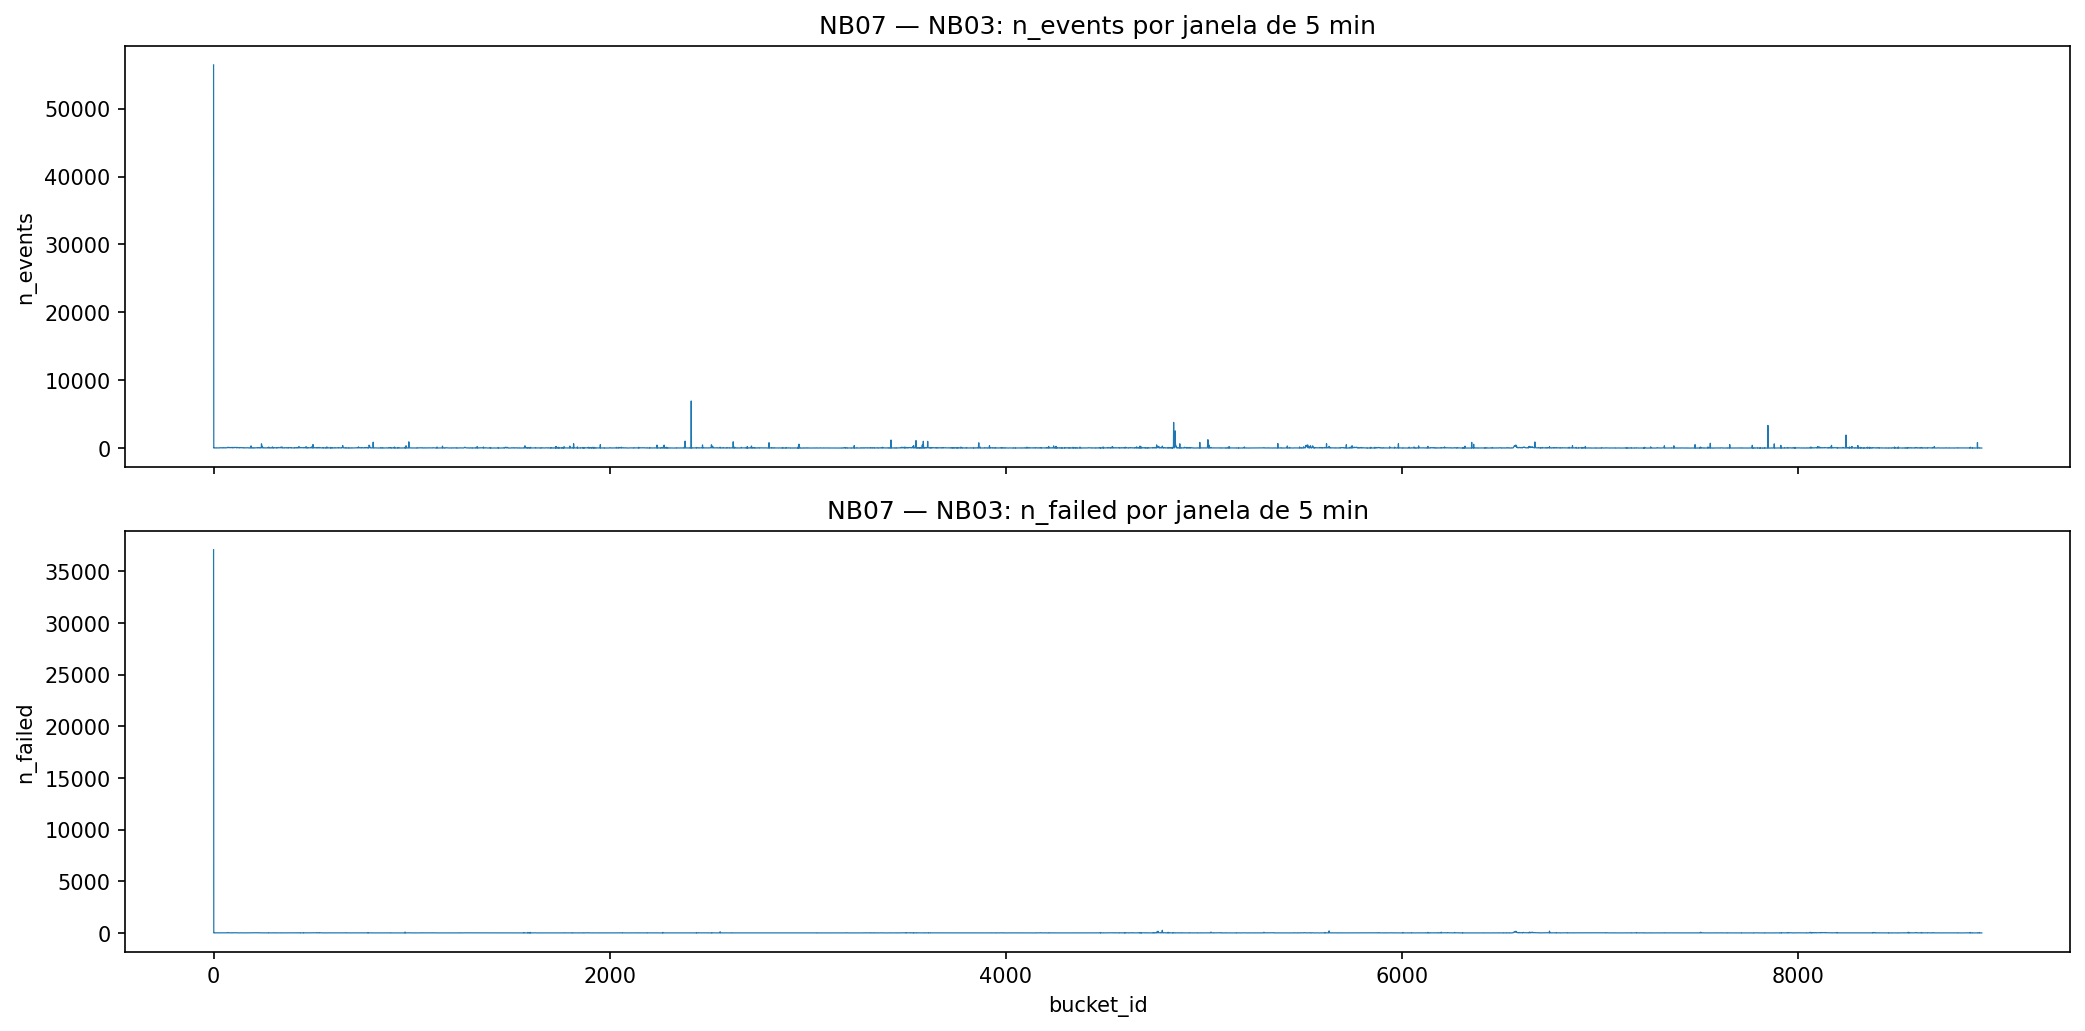

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_02_nb03_series_eventos.png
[NB07_AED_PIPELINE] NB03 base lida: 8928 linhas x 18 colunas

[Base agregada NB03]
shape                    : (8928, 18)
buckets com eventos       : 8,928
buckets na série contínua : 8,930
janelas vazias na série   : 2
[NB07_AED_PIPELINE] NB03 summary JSON carregado: /content/drive/MyDrive/Mestrado/04-reports/03_window_5min_base_summary.json

[NB07] Bloco 5 — AED NB03 concluída.

NB04 — CRITICIDADE E EPISÓDIOS
[NB07_AED_PIPELINE] NB04 summary JSON carregado: /content/drive/MyDrive/Mestrado/04-reports/04_detect_episodes_summary.json
[NB07_AED_PIPELINE] NB04 série scored lida: 8930 linhas x 20 colunas
[NB07_AED_PIPELINE] NB04 episódios lidos: 285 linhas x 18 colunas

[Parâmetros oficiais NB04 — official_result]
cenário            : global_full_series
µ                  : 0.196580
σ                  : 0.140911
limiar µ+2σ        : 0.478401
janelas críticas 

,count
is_critical,
0,8540
1,390


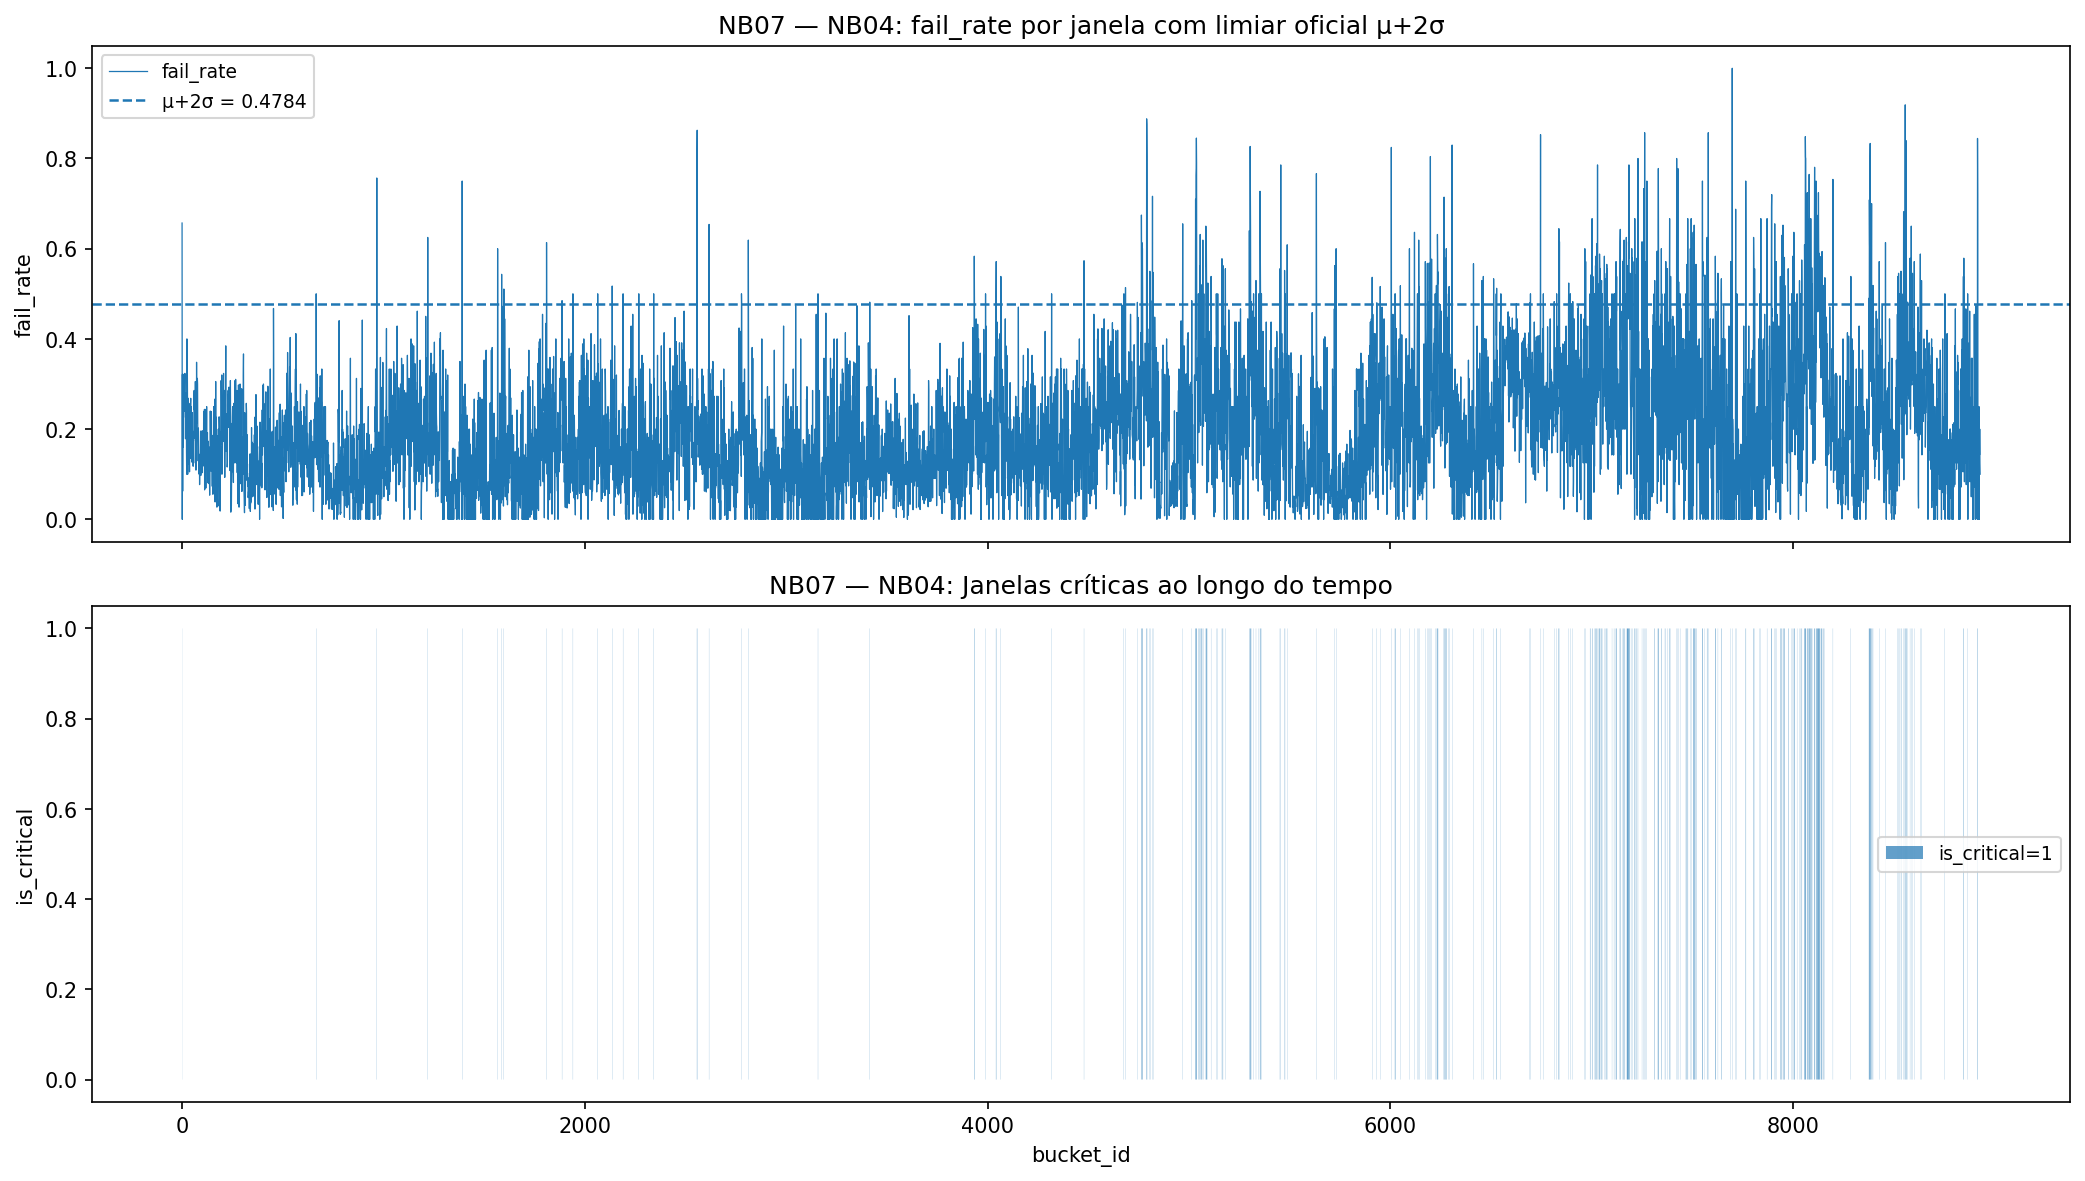

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_03_nb04_fail_rate_e_criticos.png


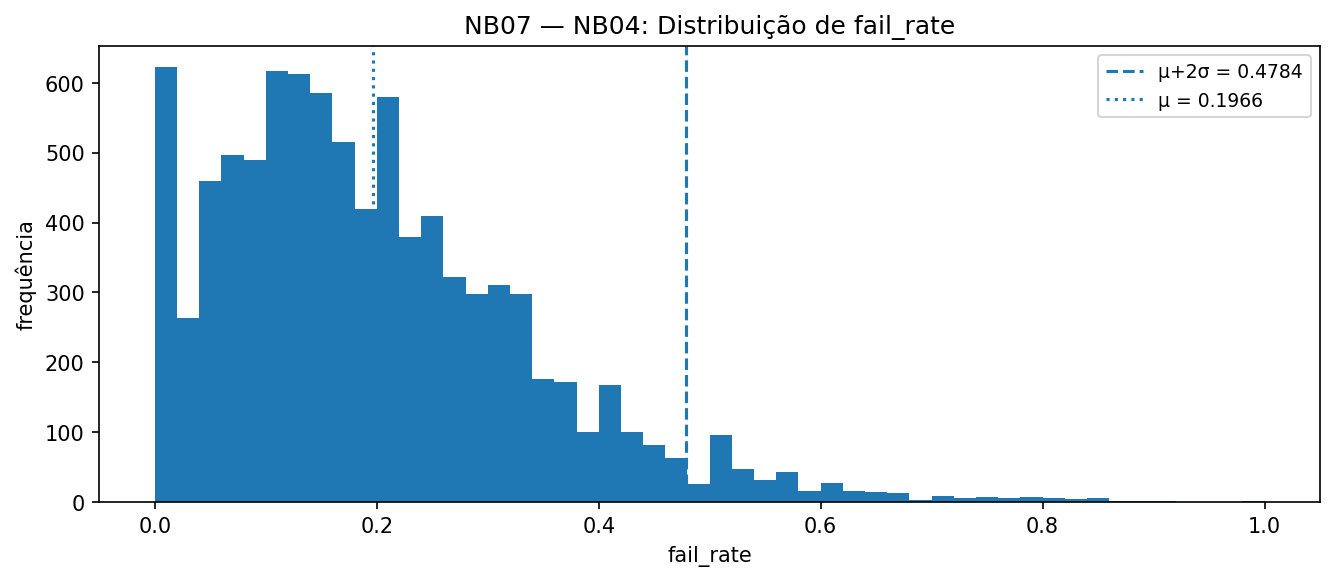

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_04_nb04_fail_rate_hist.png

[Episódios NB04]
shape: (285, 18)
colunas: ['scenario', 'episode_id', 'start_bucket', 'end_bucket', 'start_bucket_start_us', 'end_bucket_start_us', 'duration_windows', 'duration_minutes', 'max_fail_rate', 'mean_fail_rate', 'max_failed', 'mean_failed', 'sum_failed', 'max_events', 'mean_events', 'threshold', 'mu', 'sigma']

[Estatísticas de duração dos episódios — janelas]


,duration_windows
count,285.000000
mean,1.368421
std,0.904441
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,7.000000


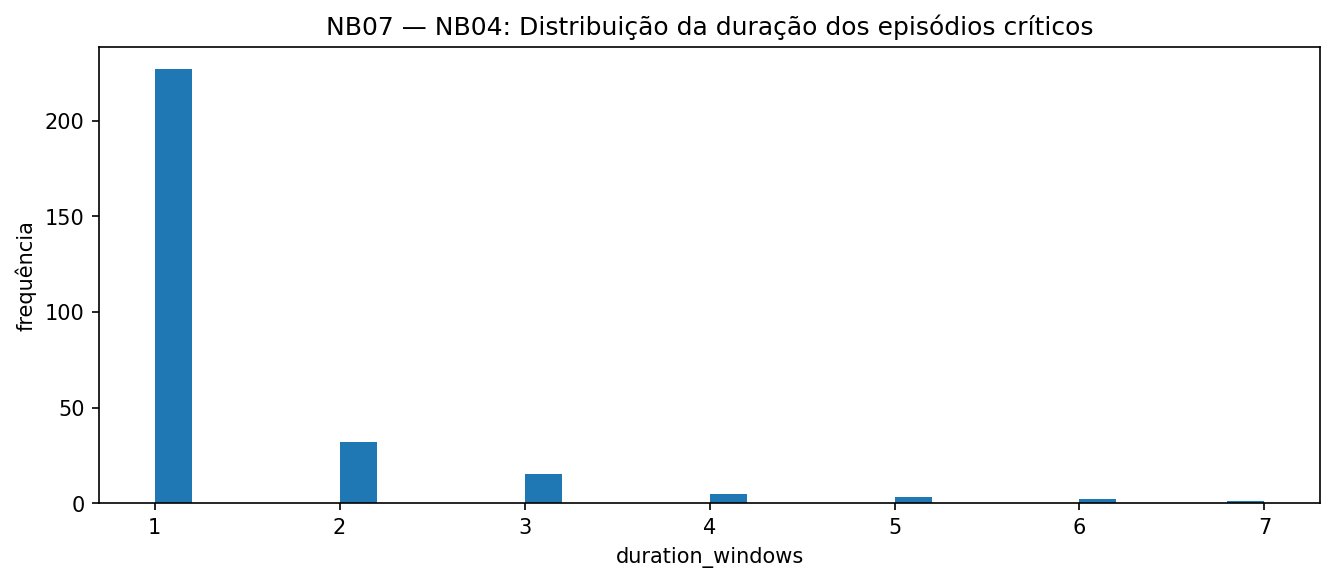

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_05_nb04_episode_duration.png

[Sensibilidade NB04 — train_only_threshold]
µ                  : 0.181582
σ                  : 0.126378
threshold          : 0.434339
critical_windows   : 562
episodes_detected  : 388

[Diagnóstico NB04 — without_bucket0]
µ                  : 0.196528
σ                  : 0.140834
threshold          : 0.478196
critical_windows   : 394
episodes_detected  : 285

[Comparativo NB00 exploratório → NB04 oficial]
µ NB00 exploratório   : 0.196580
µ NB04 oficial        : 0.196580
Δµ                    : +0.000000
thr NB00 exploratório : 0.478401
thr NB04 oficial      : 0.478401
Δthr                  : +0.000001

[NB07] Bloco 6 — AED NB04 concluída.

NB05 — FEATURES ENGENHEIRADAS (window_5min_features.parquet)
[NB07_AED_PIPELINE] NB05 lido: 8927 linhas x 28 colunas

[Shape NB05]
(8927, 28)

[Colunas NB05]
['bucket_id', 'bucket_start_us', 'n_events', 'n_failed',

,resultado
0,Sem NaN



[Estatísticas descritivas — NB05 numéricas]


,count,mean,std,min,25%,50%,75%,max
bucket_id,8927.0,4.466000e+03,2.577147e+03,3.000000e+00,2.234500e+03,4.466000e+03,6.697500e+03,8.929000e+03
bucket_start_us,8927.0,1.339800e+12,7.731442e+11,9.000000e+08,6.703500e+11,1.339800e+12,2.009250e+12,2.678700e+12
n_events,8927.0,3.914092e+01,1.132108e+02,0.000000e+00,1.700000e+01,2.600000e+01,3.900000e+01,6.941000e+03
n_failed,8927.0,6.226840e+00,9.060454e+00,0.000000e+00,2.000000e+00,4.000000e+00,8.000000e+00,2.540000e+02
n_machines,8927.0,3.823031e+01,1.128286e+02,0.000000e+00,1.600000e+01,2.500000e+01,3.800000e+01,6.938000e+03
n_collections,8927.0,1.509712e+01,7.079229e+00,0.000000e+00,1.000000e+01,1.400000e+01,1.900000e+01,5.400000e+01
mean_priority,8927.0,1.508907e+02,6.275591e+01,0.000000e+00,1.064069e+02,1.429062e+02,1.910583e+02,3.600000e+02
mean_req_cpus,8927.0,1.293059e-02,1.043086e-02,0.000000e+00,8.269228e-03,1.073408e-02,1.449382e-02,3.516285e-01
mean_req_mem,8927.0,7.265893e-03,7.241299e-03,0.000000e+00,3.219163e-03,5.212567e-03,9.006605e-03,1.859119e-01
req_cpus_presence_rate,8927.0,9.998880e-01,1.058386e-02,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


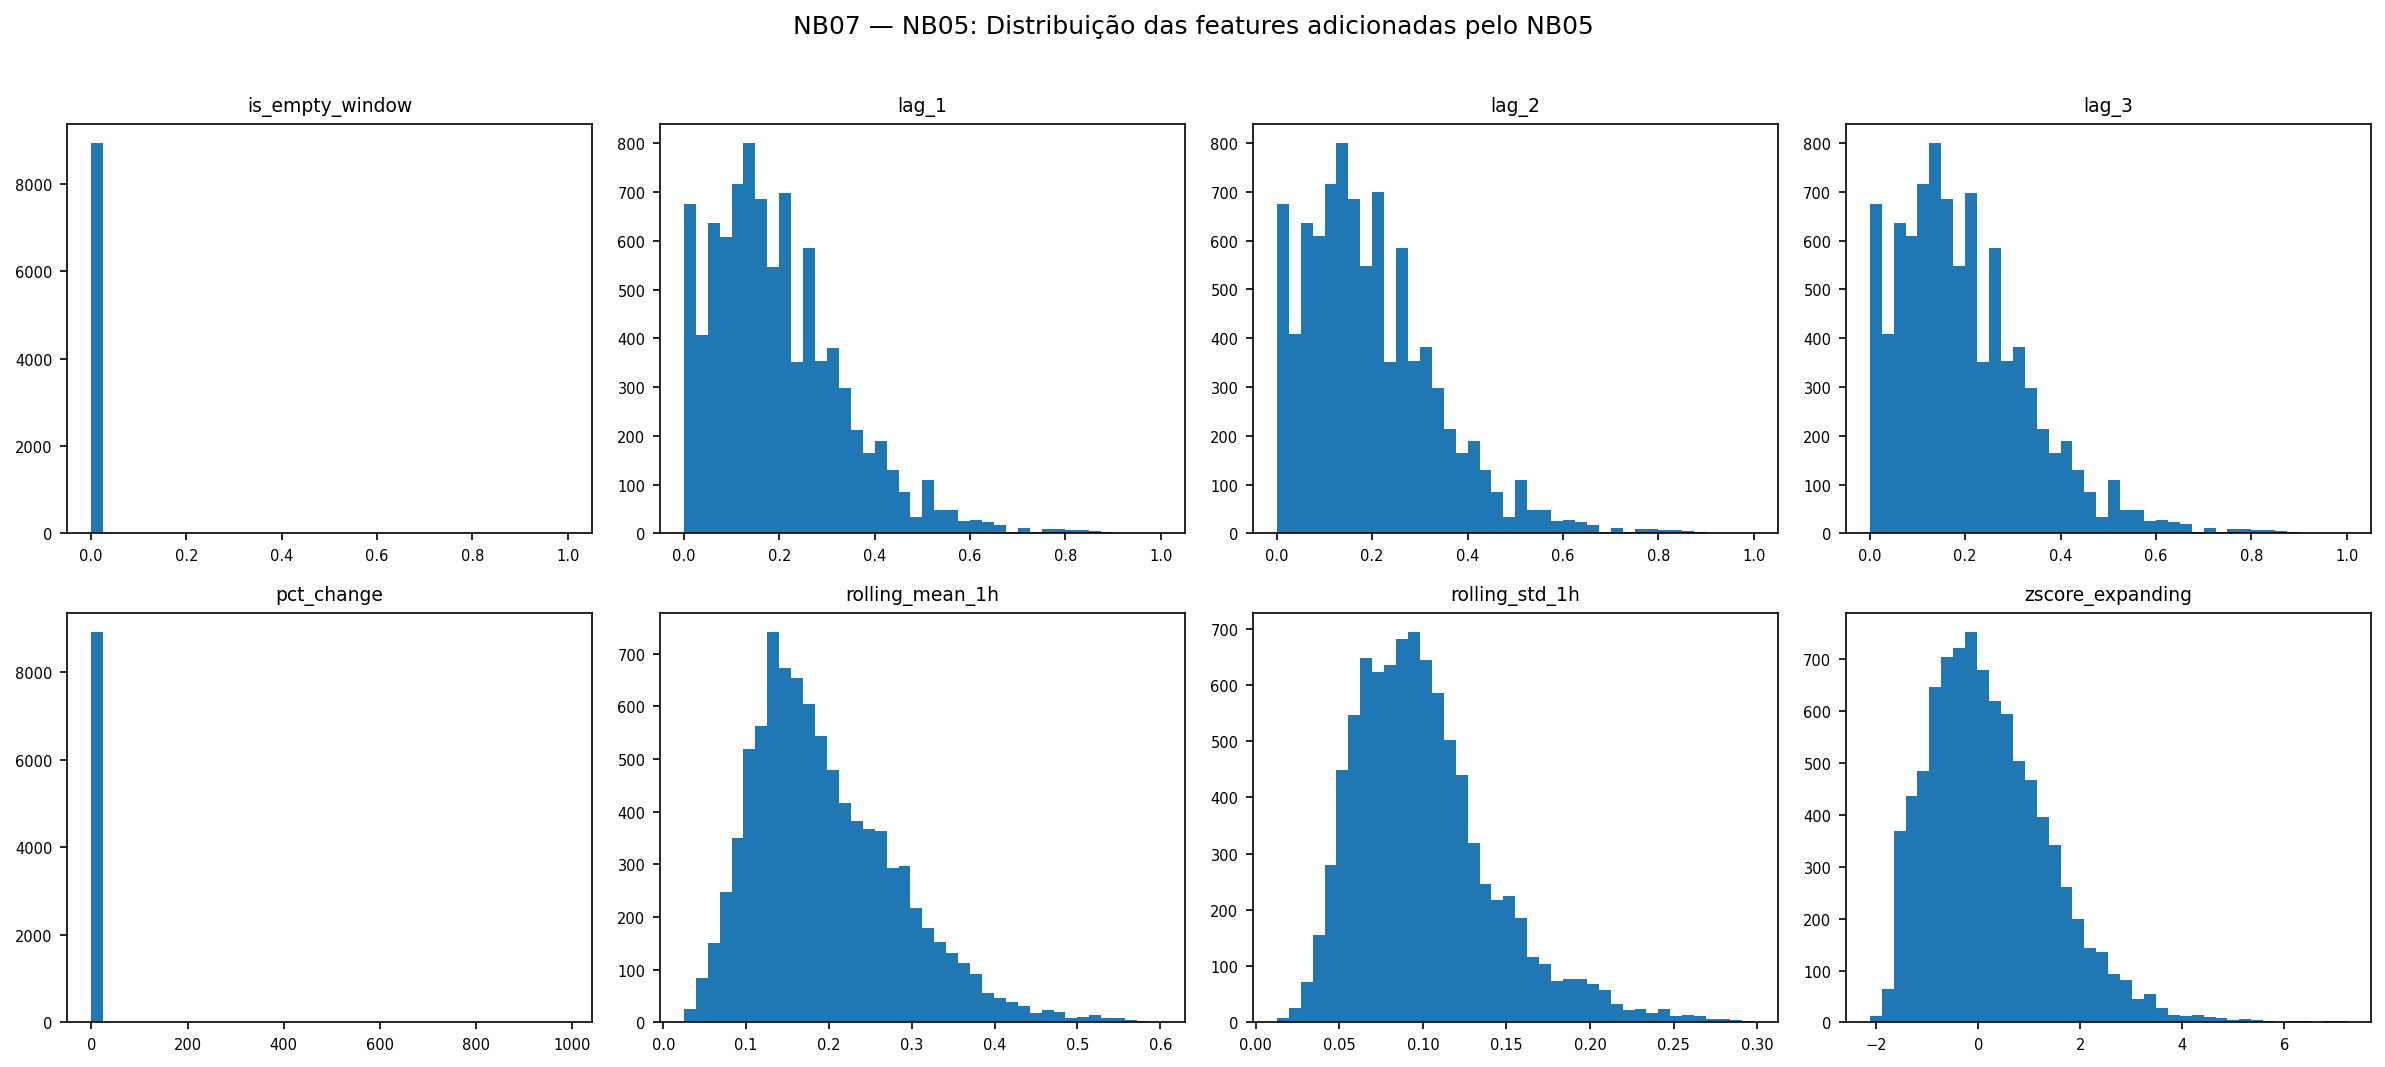

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_06_nb05_feature_distributions.png


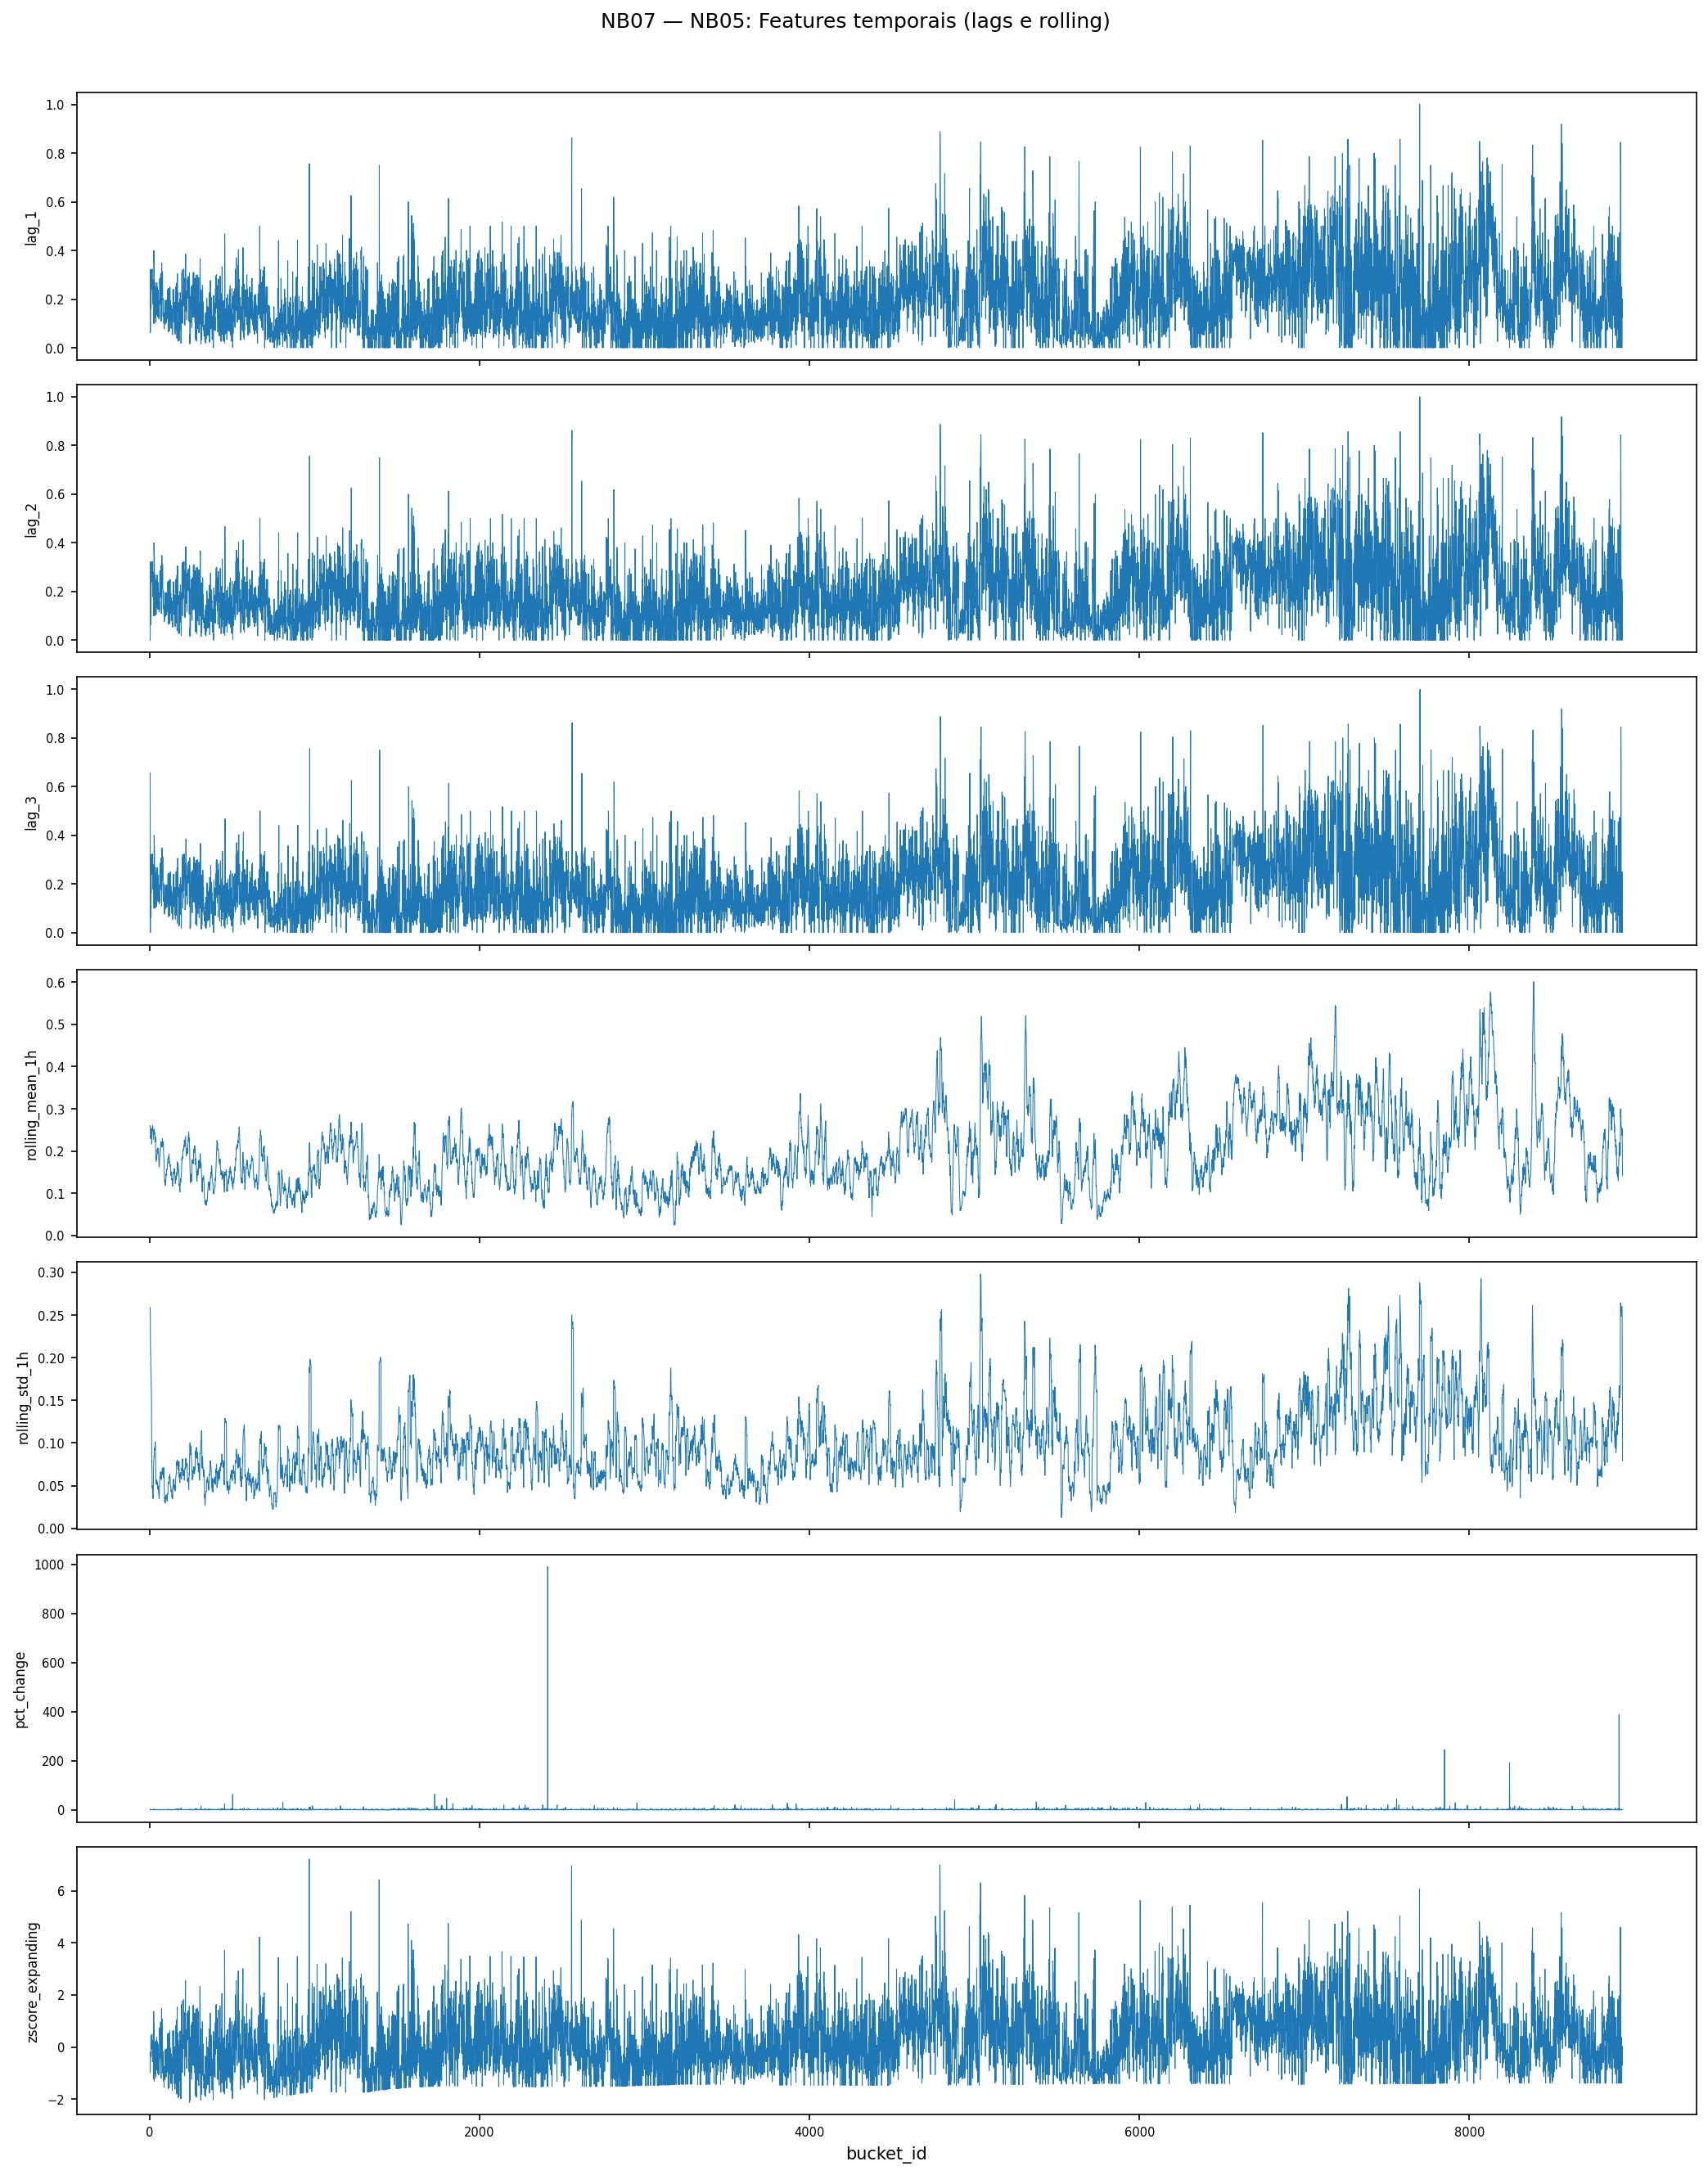

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_07_nb05_temporal_features.png


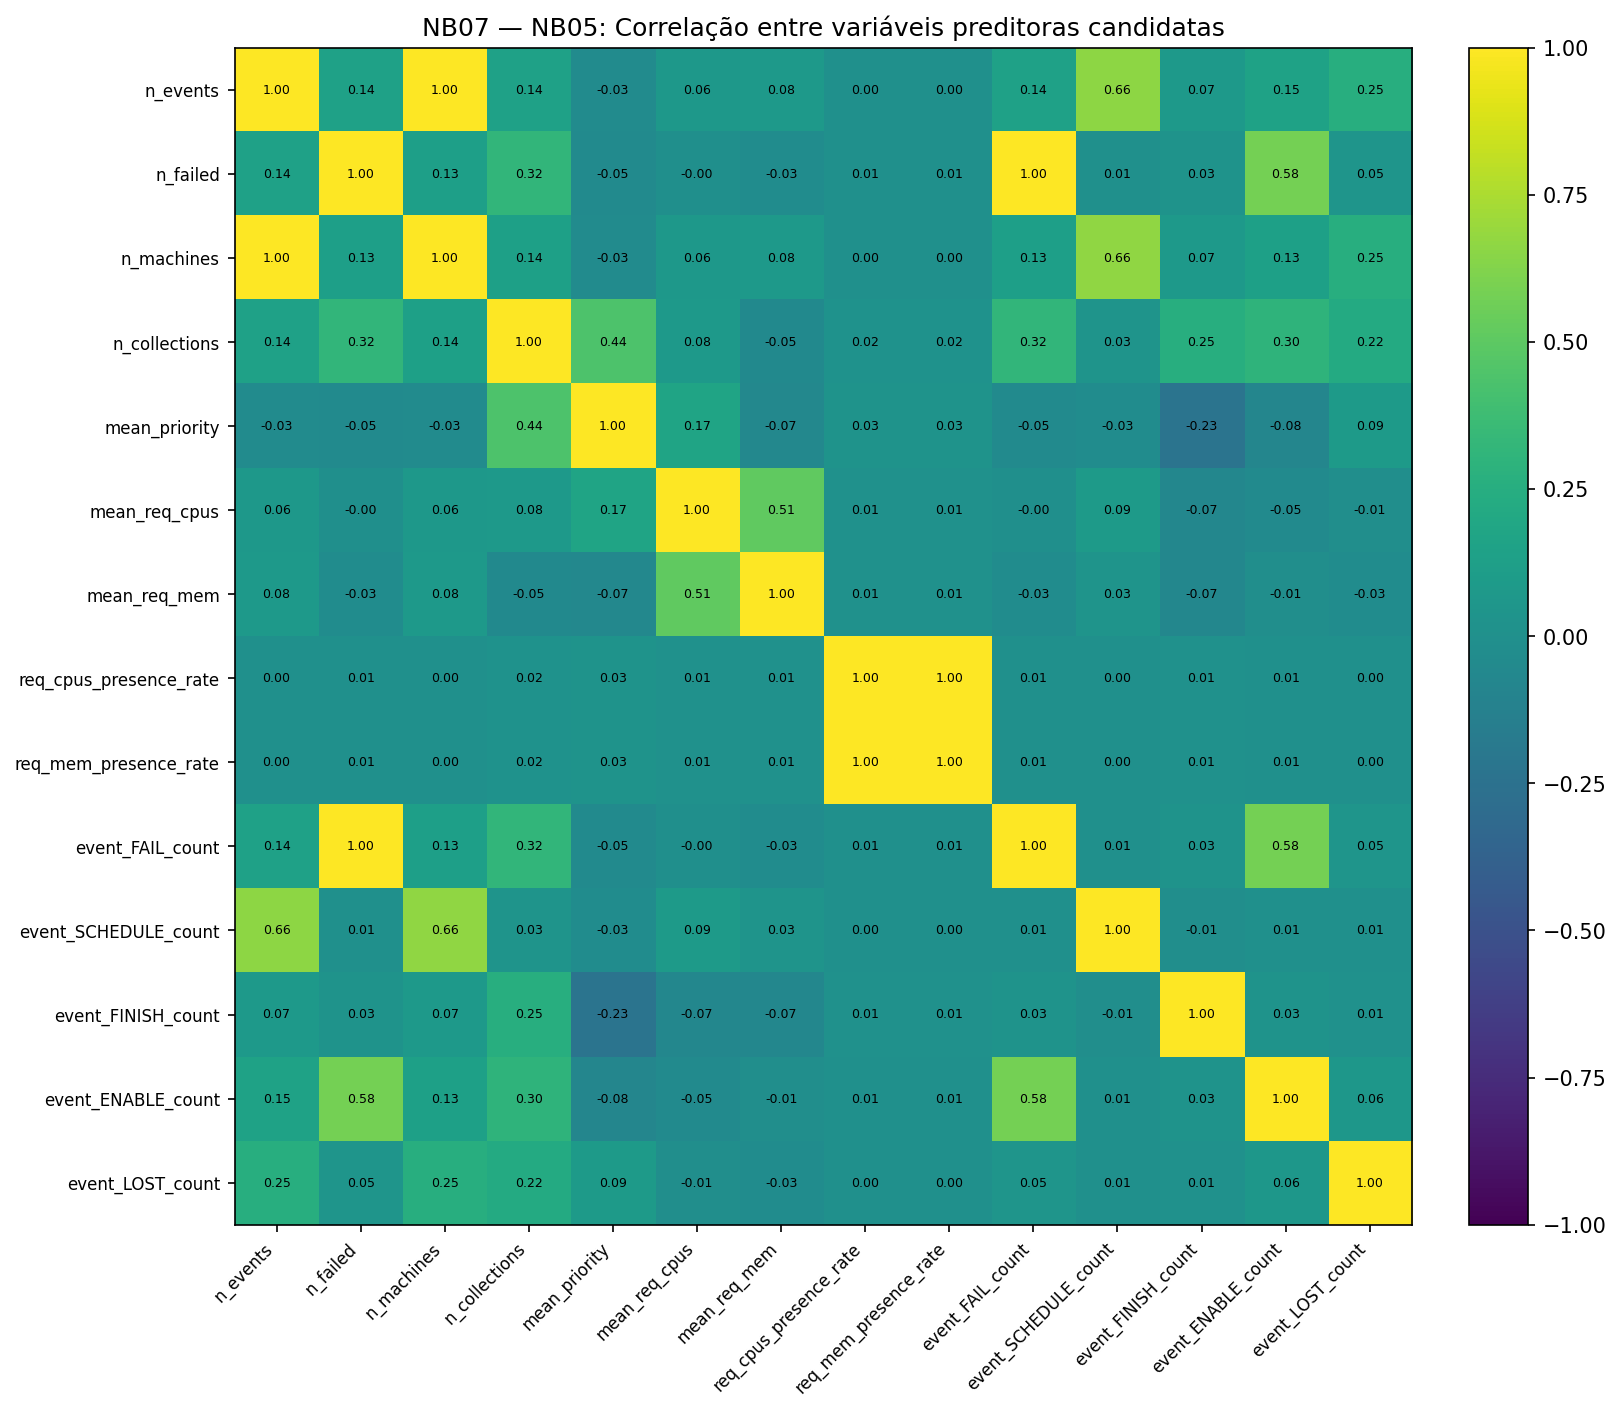

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_08_nb05_correlations.png
[NB07_AED_PIPELINE] NB05 summary JSON carregado: /content/drive/MyDrive/Mestrado/04-reports/05_feature_engineering_summary.json

[NB07] Bloco 7 — AED NB05 concluída.

NB06 — ESTADOS OPERACIONAIS (window_5min_labeled.parquet)
[NB07_AED_PIPELINE] NB06 labeled lido: 8927 linhas x 43 colunas

[Shape NB06 labeled]
(8927, 43)

[Colunas NB06 labeled]
['bucket_id', 'bucket_start_us', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'mean_priority', 'mean_req_cpus', 'mean_req_mem', 'req_cpus_presence_rate', 'req_mem_presence_rate', 'event_FAIL_count', 'event_SCHEDULE_count', 'event_FINISH_count', 'event_ENABLE_count', 'event_LOST_count', 'event_EVICT_count', 'event_KILL_count', 'fail_rate', 'is_critical', 'is_empty_window', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_1h', 'rolling_std_1h', 'pct_change', 'zscore_expanding', 'state', 'state_rank', 'state_window_k'

,count,pct
state,,
NORMAL,4301,48.18
BEFORE,2966,33.23
AFTER,1271,14.24
DURING,389,4.36


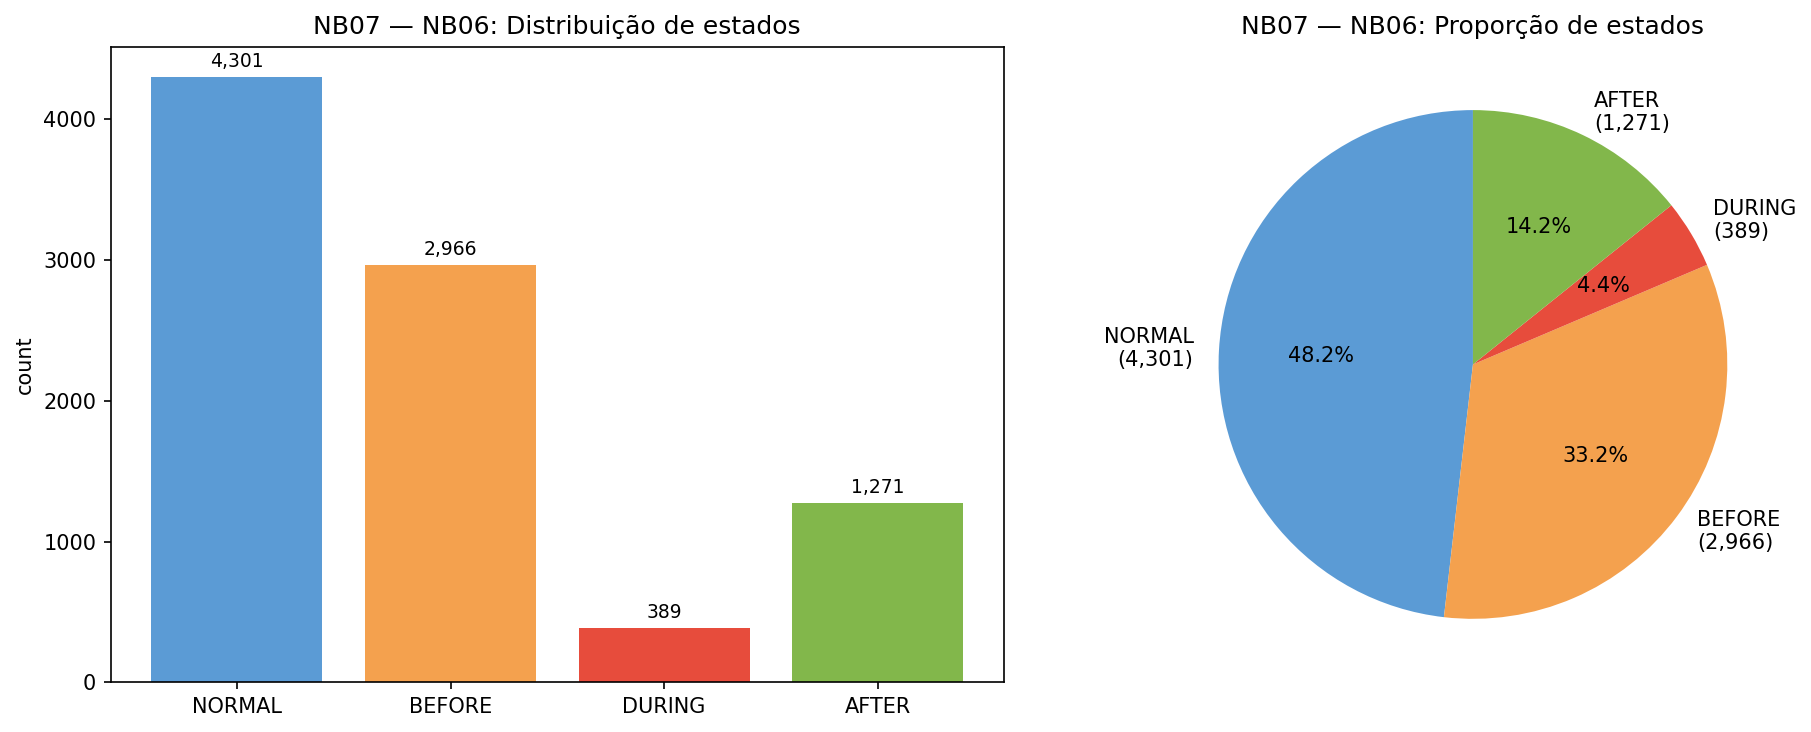

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_09_nb06_state_distribution.png


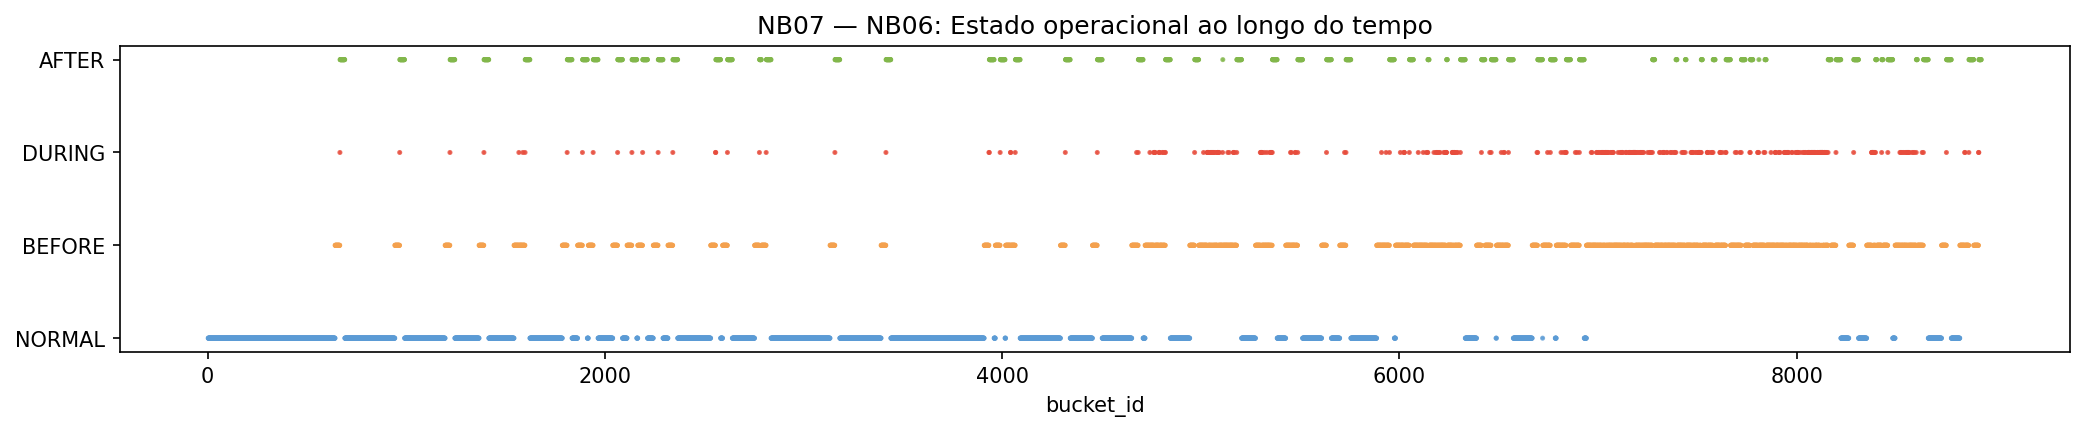

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_10_nb06_state_temporal.png

NB06 — DATASET SUPERVISIONADO (anticipation_supervised_dataset.parquet)
Cenário primary_K24_H12: K=24, H=12, horizonte=60 min
[NB07_AED_PIPELINE] NB06 supervisionado lido: 7267 linhas x 47 colunas

[Shape NB06 supervisionado]
(7267, 47)

[Colunas NB06 supervisionado]
['bucket_id', 'bucket_start_us', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'mean_priority', 'mean_req_cpus', 'mean_req_mem', 'req_cpus_presence_rate', 'req_mem_presence_rate', 'event_FAIL_count', 'event_SCHEDULE_count', 'event_FINISH_count', 'event_ENABLE_count', 'event_LOST_count', 'event_EVICT_count', 'event_KILL_count', 'fail_rate', 'is_critical', 'is_empty_window', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_1h', 'rolling_std_1h', 'pct_change', 'zscore_expanding', 'state', 'state_rank', 'state_window_k', 'next_bucket_id', 'next_state', 'is_last_window', 'has_valid_next', 'tran

,count,pct
transition_target,,
0,5280,72.66
1,1987,27.34



[Desbalanceamento]
positivos        : 1,987
negativos        : 5,280
razão pos/neg    : 0.376326
taxa positiva    : 27.34%


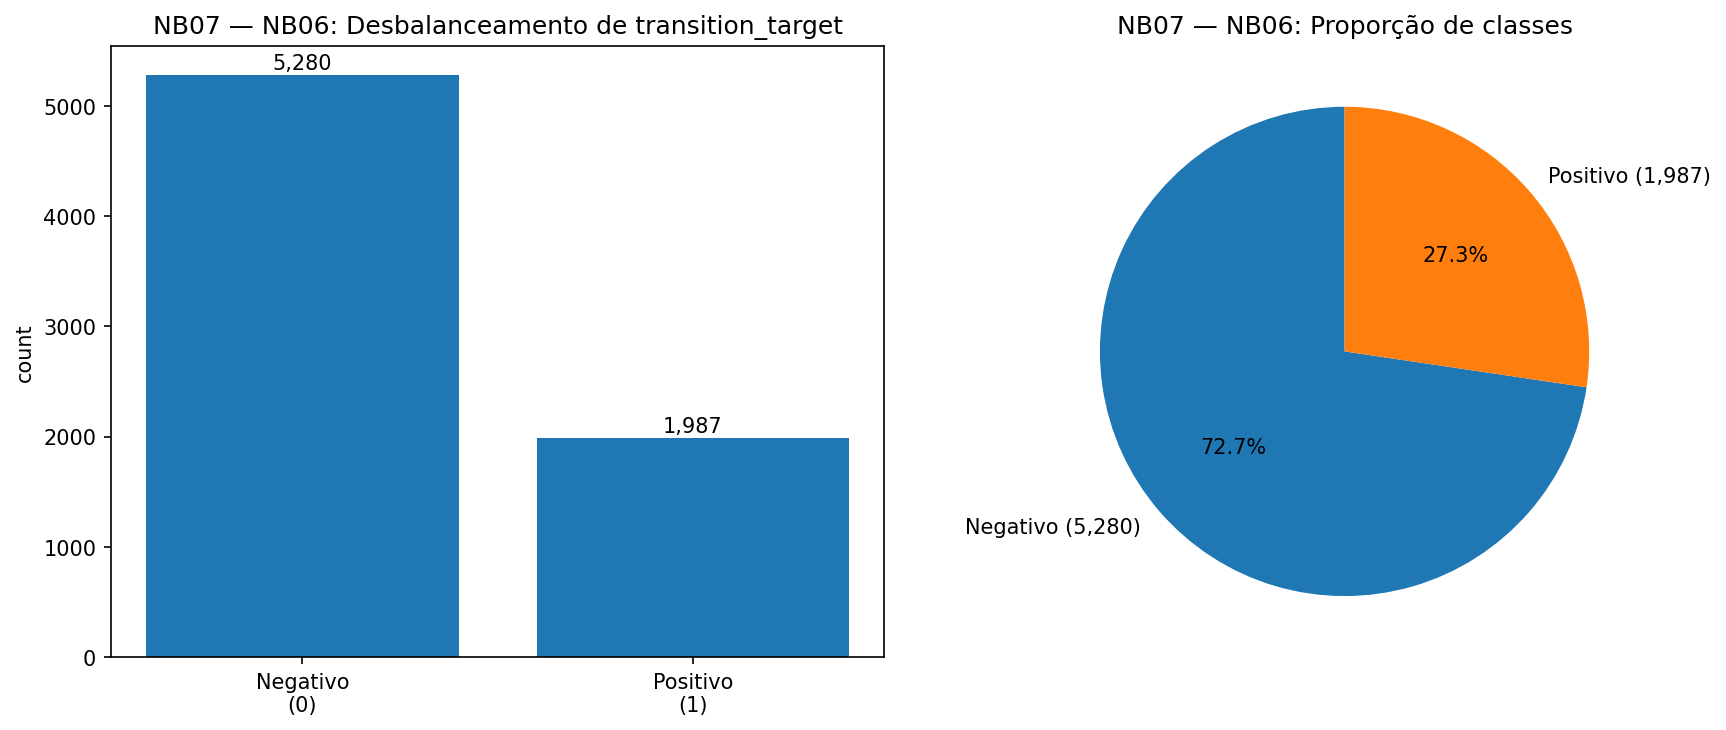

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_11_nb06_target_distribution.png

[Tabela state × transition_target]


transition_target,0,1
state,,
BEFORE,979,1987
NORMAL,4301,0


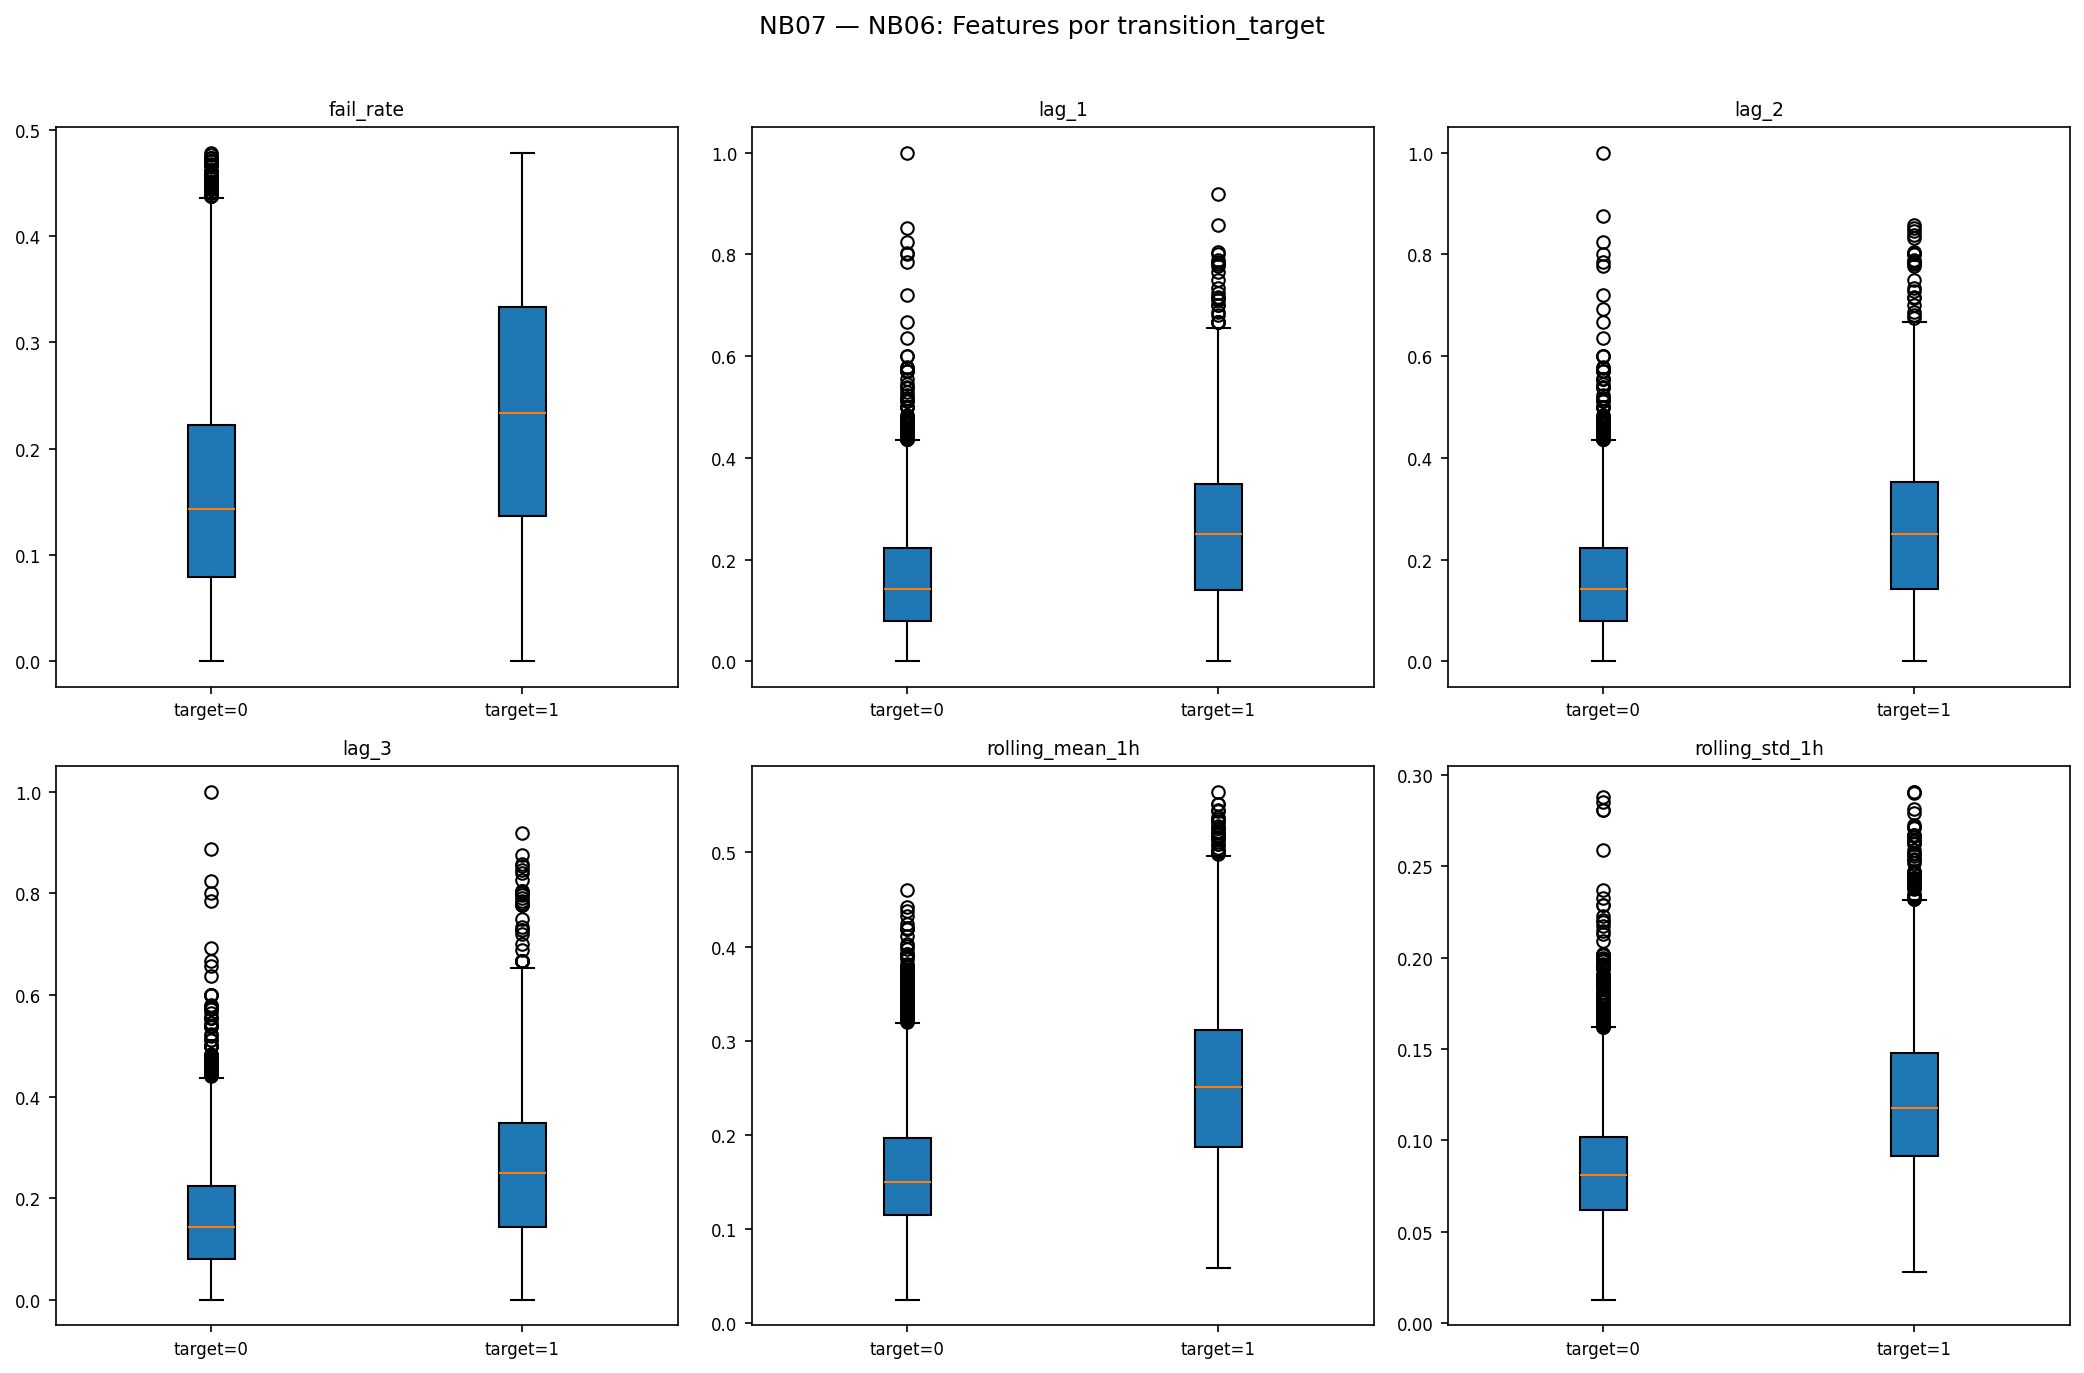

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_12_nb06_features_by_target.png
[NB07_AED_PIPELINE] NB06 summary JSON carregado: /content/drive/MyDrive/Mestrado/04-reports/06_labeling_states_summary.json

[NB07] Bloco 8 — AED NB06 concluída.

NB07 — FLUXO DE LINHAS NB00 → NB06 E CONSOLIDAÇÃO

[Fluxo de linhas ao longo do pipeline]


,Etapa,Linhas
0,NB00 (bruto CSV),"405,894"
1,NB01 (validado),"405,891"
2,NB02 (limpo),"405,891"
3,NB03 (série 5min),"8,930"
4,NB05 (features),"8,927"
5,NB06 (rotulado),"8,927"
6,NB06 (supervisionado K24H12),"7,267"


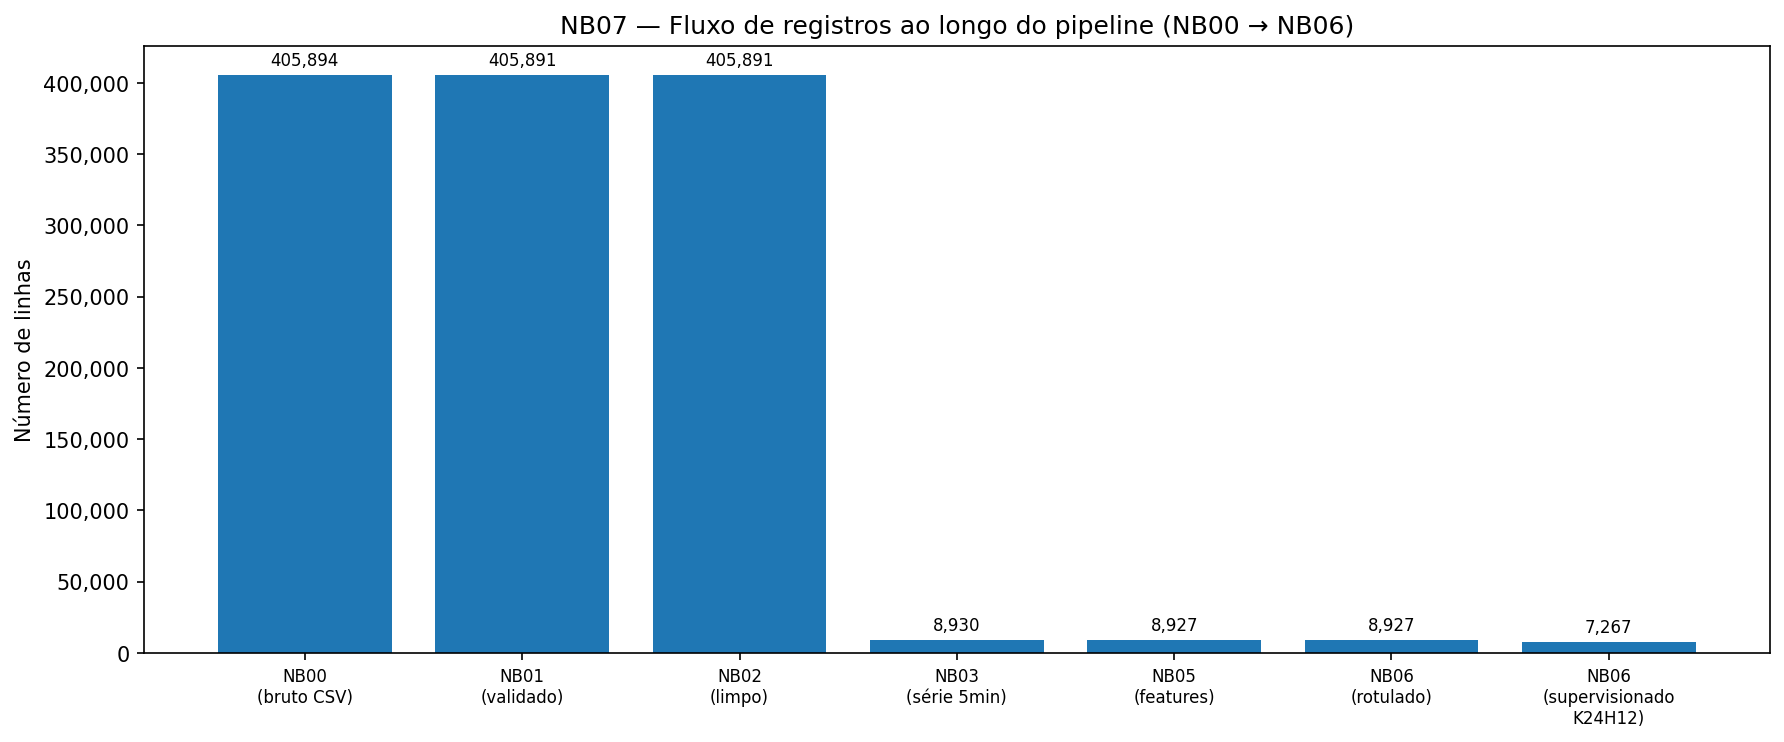

[NB07_AED_PIPELINE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb07_aed_pipeline/fig_13_pipeline_row_flow.png

[Achados exploratórios principais — NB07]
 - NB01 preservou 405,891 de 405,894 registros do CSV bruto (99.9993% de retenção), removendo apenas 3 registros.
 - NB02 manteve o cenário 'keep_hour0', com remove_hour_zero=False, preservando 56,740 registros no bloco hour==0.
 - NB03 gerou 8,930 janelas de 5 minutos (bucket 0..8929), com 0 buckets ausentes na sequência e 2 janelas sem eventos.
 - NB04, no cenário oficial 'global_full_series', calculou µ=0.1966, σ=0.1409, limiar µ+2σ=0.4784; 390 janelas críticas e 285 episódios foram detectados.
 - A sensibilidade com limiar calculado apenas sobre treino resultou em threshold=0.4343, 562 janelas críticas e 388 episódios, indicando maior sensibilidade que o limiar oficial global.
 - O diagnóstico sem bucket 0 manteve 285 episódios, com threshold=0.4782, sugerindo que a remoção diagnóstica do bucket inicial não al

In [1]:
# ============================================================
# NB07 — AED dos Artefatos do Pipeline (NB01–NB06)
# Pipeline PPCOMP_DM
#
# CÉLULA ÚNICA CONSOLIDADA
#
# Escopo:
# - Não lê diretamente o CSV bruto borg_traces_data.csv
# - Lê summaries e artefatos produzidos por NB00 a NB06
# - Realiza AED dos artefatos intermediários do pipeline
# - Não realiza modelagem
# - Não utiliza artefatos de NB08/NB09
# ============================================================

# ─────────────────────────────────────────────────────────────
# BLOCO 1 — Bootstrap, imports e configuração
# ─────────────────────────────────────────────────────────────

from google.colab import drive

drive.mount("/content/drive", force_remount=False)

import importlib
import json
import math
import random
import subprocess
import sys
import warnings
from importlib.machinery import PathFinder
from pathlib import Path

warnings.filterwarnings("ignore")

REPO_DIR = Path("/content/drive/MyDrive/Mestrado/PPCOMP_DM")
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

if not REPO_DIR.exists():
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", GITHUB_REPO, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=False)

repo_str = str(REPO_DIR)
if repo_str in sys.path:
    sys.path.remove(repo_str)
sys.path.insert(0, repo_str)

importlib.invalidate_caches()

if PathFinder not in sys.meta_path:
    sys.meta_path.append(PathFinder)

(REPO_DIR / "src").mkdir(parents=True, exist_ok=True)
init_file = REPO_DIR / "src" / "__init__.py"
if not init_file.exists():
    init_file.write_text("# src package\n", encoding="utf-8")


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    """Garante que um pacote esteja disponível no ambiente Colab."""
    try:
        importlib.import_module(import_name)
    except ImportError:
        package = pip_name or import_name
        print(f"[NB07] Instalando dependência ausente: {package}")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package],
            check=True,
        )
        importlib.invalidate_caches()


ensure_package("pyarrow")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Image, display
from importlib import reload

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    import src.paths as _paths

    reload(_paths)
    from src.paths import (
        FEATURES_PATH,
        PROCESSED_PATH,
        RAW_PATH,
        REPORTS_PATH,
        ensure_dirs,
    )

    ensure_dirs()
except Exception as exc:
    print(
        "[NB07] Aviso: não foi possível importar src.paths. "
        f"Usando paths padrão. Detalhe: {exc}"
    )
    RAW_PATH = Path("/content/drive/MyDrive/Mestrado/02-datasets/01-raw")
    PROCESSED_PATH = Path("/content/drive/MyDrive/Mestrado/02-datasets/02-processed")
    FEATURES_PATH = Path("/content/drive/MyDrive/Mestrado/02-datasets/03-features")
    REPORTS_PATH = Path("/content/drive/MyDrive/Mestrado/04-reports")

    for path in [RAW_PATH, PROCESSED_PATH, FEATURES_PATH, REPORTS_PATH]:
        path.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

FIG_DIR = REPORTS_PATH / "figures_nb07_aed_pipeline"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Remove figuras antigas para evitar mistura de execuções.
for old_png in FIG_DIR.glob("*.png"):
    old_png.unlink()

figures_generated: list[str] = []


def log(msg: str) -> None:
    """Imprime mensagem padronizada do NB07."""
    print(f"[NB07_AED_PIPELINE] {msg}")


def save_fig(name: str, show_inline: bool = True) -> str:
    """Salva a figura corrente, exibe inline no notebook e fecha o canvas."""
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=150, bbox_inches="tight")

    if show_inline:
        display(Image(filename=str(out)))

    plt.close()
    figures_generated.append(str(out))
    log(f"Figura salva: {out}")
    return str(out)


def make_json_safe(obj):
    """Converte objetos numpy/pandas em tipos seguros para JSON."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        value = float(obj)
        return None if math.isnan(value) or math.isinf(value) else value
    if isinstance(obj, float):
        return None if math.isnan(obj) or math.isinf(obj) else obj
    if obj is None:
        return None
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    return obj


def read_json_if_exists(path: Path, label: str) -> dict:
    """Lê um JSON se existir. Caso contrário, retorna dict vazio."""
    if path.exists():
        log(f"{label} carregado: {path}")
        return json.loads(path.read_text(encoding="utf-8"))
    log(f"AVISO: {label} não encontrado: {path}")
    return {}


def require_file(path: Path, label: str) -> None:
    """Garante que um artefato obrigatório exista."""
    assert path.exists(), f"Artefato obrigatório não encontrado ({label}): {path}"


def boxplot_with_labels(ax, data, labels, **kwargs):
    """Compatibilidade com Matplotlib: labels foi renomeado para tick_labels."""
    try:
        return ax.boxplot(data, tick_labels=labels, **kwargs)
    except TypeError:
        return ax.boxplot(data, labels=labels, **kwargs)


# ─────────────────────────────────────────────────────────────
# BLOCO 2 — Paths dos artefatos
# ─────────────────────────────────────────────────────────────

NB00_RAW_JSON = REPORTS_PATH / "00_aed_raw_summary.json"
NB00_AED_JSON = REPORTS_PATH / "00_aed_summary.json"

NB01_PARQUET = PROCESSED_PATH / "trace_raw_validated.parquet"
NB01_JSON = REPORTS_PATH / "01_ingest_validate_summary.json"

NB02_PARQUET = PROCESSED_PATH / "google_trace_clean.parquet"
NB02_JSON = REPORTS_PATH / "02_clean_normalize_summary.json"

NB03_SERIES = FEATURES_PATH / "window_5min_series.parquet"
NB03_BASE = FEATURES_PATH / "window_5min_base.parquet"
NB03_JSON = REPORTS_PATH / "03_window_5min_base_summary.json"

NB04_SCORED = FEATURES_PATH / "window_5min_series_scored.parquet"
NB04_EPISODES = FEATURES_PATH / "episodes_detected.parquet"
NB04_JSON = REPORTS_PATH / "04_detect_episodes_summary.json"

NB04_SCORED_TRAIN_THRESHOLD = (
    FEATURES_PATH / "window_5min_series_scored_train_threshold.parquet"
)
NB04_EPISODES_TRAIN_THRESHOLD = (
    FEATURES_PATH / "episodes_detected_train_threshold.parquet"
)

NB05_FEATURES = FEATURES_PATH / "window_5min_features.parquet"
NB05_JSON = REPORTS_PATH / "05_feature_engineering_summary.json"

NB06_LABELED = FEATURES_PATH / "window_5min_labeled.parquet"
NB06_SUPERV = FEATURES_PATH / "anticipation_supervised_dataset.parquet"
NB06_JSON = REPORTS_PATH / "06_labeling_states_summary.json"

SUMMARY_FILE = REPORTS_PATH / "07_aed_pipeline_summary.json"

print("\n===== PATHS =====")
print("REPO_DIR       :", REPO_DIR)
print("PROCESSED_PATH :", PROCESSED_PATH)
print("FEATURES_PATH  :", FEATURES_PATH)
print("REPORTS_PATH   :", REPORTS_PATH)
print("FIG_DIR        :", FIG_DIR)


# ─────────────────────────────────────────────────────────────
# BLOCO 3 — Referências NB00
# ─────────────────────────────────────────────────────────────

raw_ref = read_json_if_exists(NB00_RAW_JSON, "Referência NB00 raw")
nb00_aed_ref = read_json_if_exists(NB00_AED_JSON, "Referência NB00 consolidada")

raw_rows = (
    raw_ref.get("raw_rows_loaded")
    or raw_ref.get("raw_rows")
    or raw_ref.get("rows")
)

nb00_exploratory_stats = (
    nb00_aed_ref
    .get("exploratory_series", {})
    .get("stats_all_windows", {})
)

nb00_exploratory_mu = nb00_exploratory_stats.get("fail_rate_mean")
nb00_exploratory_threshold = nb00_exploratory_stats.get(
    "threshold_mu_plus_2sigma"
)

summary = {
    "notebook": "NB07",
    "title": "Análise Exploratória dos Artefatos do Pipeline",
    "purpose": "aed_pipeline_artifacts_nb01_to_nb06",
    "reads_raw_csv_directly": False,
    "uses_pipeline_artifacts_nb01_to_nb06": True,
    "uses_modeling_artifacts_nb08_nb09": False,
    "nb00_raw_reference_loaded": bool(raw_ref),
    "nb00_aed_reference_loaded": bool(nb00_aed_ref),
    "input_references": {
        "nb00_raw_summary": str(NB00_RAW_JSON),
        "nb00_aed_summary": str(NB00_AED_JSON),
    },
    "figures": [],
}

print("\n[NB07] Bloco 3 — Referências NB00 concluído.")


# ─────────────────────────────────────────────────────────────
# BLOCO 4 — AED NB01 e NB02
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 80)
print("NB01 — DATASET VALIDADO (trace_raw_validated.parquet)")
print("=" * 80)

require_file(NB01_PARQUET, "NB01 parquet")
df01 = pd.read_parquet(NB01_PARQUET)
log(f"NB01 lido: {df01.shape[0]} linhas x {df01.shape[1]} colunas")

print("\n[Shape NB01]")
print(df01.shape)

print("\n[Tipos de dados NB01]")
display(df01.dtypes.to_frame("dtype"))

miss01 = df01.isna().sum()
miss01_pct = (df01.isna().mean() * 100).round(2)
miss_df01 = pd.DataFrame({"missing_count": miss01, "missing_pct": miss01_pct})
miss_df01 = miss_df01[miss_df01["missing_count"] > 0].sort_values(
    "missing_pct",
    ascending=False,
)

print("\n[Missingness NB01]")
display(miss_df01 if len(miss_df01) > 0 else pd.DataFrame({"resultado": ["Sem NaN"]}))

delta01 = None
retention01 = None
if raw_rows:
    delta01 = int(df01.shape[0] - raw_rows)
    retention01 = df01.shape[0] / raw_rows
    print("\n[Comparativo NB00 → NB01]")
    print(f"Linhas brutas NB00     : {raw_rows:,}")
    print(f"Linhas validadas NB01  : {df01.shape[0]:,}")
    print(f"Diferença              : {delta01:+,} ({delta01 / raw_rows * 100:+.4f}%)")
    print(f"Retenção               : {retention01 * 100:.4f}%")

nb01_meta = read_json_if_exists(NB01_JSON, "NB01 summary JSON")

summary["nb01"] = {
    "rows": int(df01.shape[0]),
    "cols": int(df01.shape[1]),
    "columns": list(df01.columns),
    "dtypes": {col: str(dtype) for col, dtype in df01.dtypes.items()},
    "missing_by_column": {col: int(value) for col, value in miss01.items() if value > 0},
    "missing_pct_by_column": {
        col: float(miss01_pct[col]) for col, value in miss01.items() if value > 0
    },
    "raw_rows_reference": int(raw_rows) if raw_rows else None,
    "delta_rows_vs_raw": delta01,
    "retention_vs_raw": retention01,
}

print("\n" + "=" * 80)
print("NB02 — DATASET LIMPO/NORMALIZADO (google_trace_clean.parquet)")
print("=" * 80)

require_file(NB02_PARQUET, "NB02 parquet")
df02 = pd.read_parquet(NB02_PARQUET)
log(f"NB02 lido: {df02.shape[0]} linhas x {df02.shape[1]} colunas")

print("\n[Shape NB02]")
print(df02.shape)

new_cols_nb02 = sorted(set(df02.columns) - set(df01.columns))
removed_cols_nb02 = sorted(set(df01.columns) - set(df02.columns))

print("\n[Colunas adicionadas pelo NB02 vs NB01]")
print(new_cols_nb02)

print("\n[Colunas removidas pelo NB02 vs NB01]")
print(removed_cols_nb02)

nb02_meta = read_json_if_exists(NB02_JSON, "NB02 summary JSON")

rows_h0 = nb02_meta.get("rows_hour0")
rows_out = nb02_meta.get("rows_out")
scenario = nb02_meta.get("scenario_label", "—")
remove_h0 = nb02_meta.get("remove_hour_zero")

print("\n[Decisão sobre hour == 0 — NB02]")
print(f"scenario_label   : {scenario}")
print(f"remove_hour_zero : {remove_h0}")
print(f"rows_hour0       : {rows_h0:,}" if isinstance(rows_h0, int) else "rows_hour0       : n/a")
print(f"rows_out         : {rows_out:,}" if isinstance(rows_out, int) else "rows_out         : n/a")

hourly_summary = {}
if "hour" in df02.columns:
    hourly = df02.groupby("hour").size()
    hourly_summary = {
        "hour_min": int(df02["hour"].min()),
        "hour_max": int(df02["hour"].max()),
        "hourly_volume_min": int(hourly.min()),
        "hourly_volume_max": int(hourly.max()),
        "hourly_volume_mean": float(hourly.mean()),
    }

    print("\n[Cobertura temporal NB02]")
    print(f"hour range             : {hourly_summary['hour_min']}..{hourly_summary['hour_max']}")
    print(
        "volume min/max/médio   : "
        f"{hourly.min():,} / {hourly.max():,} / {hourly.mean():.2f}"
    )

    plt.figure(figsize=(12, 4))
    plt.plot(hourly.index, hourly.values, linewidth=0.8)
    plt.xlabel("hour relativo ao início")
    plt.ylabel("n_registros")
    plt.title("NB07 — NB02: Volume de registros por hora")
    save_fig("fig_01_nb02_volume_por_hora.png")

summary["nb02"] = {
    "rows": int(df02.shape[0]),
    "cols": int(df02.shape[1]),
    "columns": list(df02.columns),
    "new_columns_vs_nb01": new_cols_nb02,
    "removed_columns_vs_nb01": removed_cols_nb02,
    "scenario_label": scenario,
    "remove_hour_zero": remove_h0,
    "rows_hour0": int(rows_h0) if isinstance(rows_h0, int) else None,
    "rows_out": int(rows_out) if isinstance(rows_out, int) else None,
    "hourly_summary": hourly_summary,
}

del df01, df02
print("\n[NB07] Bloco 4 — AED NB01/NB02 concluída.")


# ─────────────────────────────────────────────────────────────
# BLOCO 5 — AED NB03
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 80)
print("NB03 — SÉRIE CONTÍNUA DE JANELAS 5 MIN (window_5min_series.parquet)")
print("=" * 80)

require_file(NB03_SERIES, "NB03 série 5min")
df03s = pd.read_parquet(NB03_SERIES)
log(f"NB03 série lida: {df03s.shape[0]} linhas x {df03s.shape[1]} colunas")

print("\n[Shape NB03 série]")
print(df03s.shape)

print("\n[Colunas NB03 série]")
print(list(df03s.columns))

print("\n[Amostra NB03 série]")
display(df03s.head())

print("\n[Estatísticas descritivas NB03 série]")
display(df03s.describe(include="all").T)

bucket_min = int(df03s["bucket_id"].min())
bucket_max = int(df03s["bucket_id"].max())
n_buckets = int(df03s["bucket_id"].nunique())
n_expected = int(bucket_max - bucket_min + 1)
n_missing_buckets = int(n_expected - n_buckets)
n_empty_windows = int((df03s["n_events"] == 0).sum()) if "n_events" in df03s.columns else None

print("\n[Cobertura de buckets NB03]")
print(f"bucket_id range                    : {bucket_min}..{bucket_max}")
print(f"buckets únicos                     : {n_buckets:,}")
print(f"buckets esperados                  : {n_expected:,}")
print(f"buckets ausentes na sequência      : {n_missing_buckets:,}")
print(f"janelas sem eventos (n_events == 0): {n_empty_windows:,}")

bucket0_summary = {}
if (df03s["bucket_id"] == 0).any():
    b0 = df03s.loc[df03s["bucket_id"] == 0].iloc[0]
    print("\n[Bucket 0 — bloco inicial]")
    for col in ["n_events", "n_failed", "n_machines", "n_collections", "mean_priority"]:
        if col in df03s.columns:
            print(f"{col}: {b0[col]}")
            bucket0_summary[col] = make_json_safe(b0[col])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df03s["bucket_id"], df03s["n_events"], linewidth=0.6)
axes[0].set_ylabel("n_events")
axes[0].set_title("NB07 — NB03: n_events por janela de 5 min")
axes[1].plot(df03s["bucket_id"], df03s["n_failed"], linewidth=0.6)
axes[1].set_ylabel("n_failed")
axes[1].set_xlabel("bucket_id")
axes[1].set_title("NB07 — NB03: n_failed por janela de 5 min")
save_fig("fig_02_nb03_series_eventos.png")

nb03_base_rows = None
if NB03_BASE.exists():
    df03b = pd.read_parquet(NB03_BASE)
    nb03_base_rows = int(df03b.shape[0])
    log(f"NB03 base lida: {df03b.shape[0]} linhas x {df03b.shape[1]} colunas")
    print("\n[Base agregada NB03]")
    print(f"shape                    : {df03b.shape}")
    print(f"buckets com eventos       : {df03b.shape[0]:,}")
    print(f"buckets na série contínua : {df03s.shape[0]:,}")
    print(f"janelas vazias na série   : {n_empty_windows:,}")
    del df03b

nb03_meta = read_json_if_exists(NB03_JSON, "NB03 summary JSON")

summary["nb03"] = {
    "series_rows": int(df03s.shape[0]),
    "series_cols": int(df03s.shape[1]),
    "columns": list(df03s.columns),
    "bucket_min": bucket_min,
    "bucket_max": bucket_max,
    "n_unique_buckets": n_buckets,
    "n_expected_buckets": n_expected,
    "n_missing_buckets": n_missing_buckets,
    "n_empty_windows": n_empty_windows,
    "base_rows_observed_buckets": nb03_base_rows,
    "n_events_total": int(df03s["n_events"].sum()) if "n_events" in df03s.columns else None,
    "n_failed_total": int(df03s["n_failed"].sum()) if "n_failed" in df03s.columns else None,
    "avg_events_per_bucket": float(df03s["n_events"].mean()) if "n_events" in df03s.columns else None,
    "bucket0_summary": bucket0_summary,
}

del df03s
print("\n[NB07] Bloco 5 — AED NB03 concluída.")


# ─────────────────────────────────────────────────────────────
# BLOCO 6 — AED NB04
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 80)
print("NB04 — CRITICIDADE E EPISÓDIOS")
print("=" * 80)

require_file(NB04_JSON, "NB04 summary JSON")
nb04_meta = read_json_if_exists(NB04_JSON, "NB04 summary JSON")

require_file(NB04_SCORED, "NB04 série scored")
df04s = pd.read_parquet(NB04_SCORED)

require_file(NB04_EPISODES, "NB04 episodes")
df04e = pd.read_parquet(NB04_EPISODES)

log(f"NB04 série scored lida: {df04s.shape[0]} linhas x {df04s.shape[1]} colunas")
log(f"NB04 episódios lidos: {df04e.shape[0]} linhas x {df04e.shape[1]} colunas")

official_result = nb04_meta.get("official_result", {})
train_sensitivity = nb04_meta.get("train_threshold_sensitivity_result", {})
without_bucket0 = nb04_meta.get("without_bucket0_diagnostic", {})
bucket0_nb04 = nb04_meta.get("bucket0_summary", {})

if not official_result:
    log("AVISO: official_result não encontrado. Usando fallback nos artefatos NB04.")

mu04 = float(official_result.get("mu", df04s["fail_rate"].mean()))
sigma04 = float(official_result.get("sigma", df04s["fail_rate"].std(ddof=0)))
thr04 = float(official_result.get("threshold", mu04 + 2 * sigma04))
n_critical04 = int(official_result.get("critical_windows", df04s["is_critical"].sum()))
n_episodes04 = int(official_result.get("episodes_detected", len(df04e)))

n_critical_df = int(df04s["is_critical"].sum())
n_episodes_df = int(len(df04e))

print("\n[Parâmetros oficiais NB04 — official_result]")
print(f"cenário            : {official_result.get('scenario', 'n/a')}")
print(f"µ                  : {mu04:.6f}")
print(f"σ                  : {sigma04:.6f}")
print(f"limiar µ+2σ        : {thr04:.6f}")
print(f"janelas críticas   : {n_critical04}")
print(f"episódios          : {n_episodes04}")

print("\n[Conferência contra os artefatos Parquet]")
print(f"is_critical.sum() no scored parquet : {n_critical_df}")
print(f"len(episodes_detected.parquet)      : {n_episodes_df}")

if n_critical04 != n_critical_df:
    log(f"AVISO: critical_windows do JSON ({n_critical04}) difere do parquet ({n_critical_df}).")
if n_episodes04 != n_episodes_df:
    log(f"AVISO: episodes_detected do JSON ({n_episodes04}) difere do parquet ({n_episodes_df}).")

print("\n[Colunas NB04 scored]")
print(list(df04s.columns))

print("\n[Distribuição is_critical]")
crit_counts = df04s["is_critical"].value_counts(dropna=False).sort_index()
display(crit_counts.to_frame("count"))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df04s["bucket_id"], df04s["fail_rate"], linewidth=0.6, label="fail_rate")
axes[0].axhline(thr04, linestyle="--", linewidth=1.2, label=f"µ+2σ = {thr04:.4f}")
axes[0].set_ylabel("fail_rate")
axes[0].set_title("NB07 — NB04: fail_rate por janela com limiar oficial µ+2σ")
axes[0].legend(fontsize=9)
axes[1].fill_between(df04s["bucket_id"], df04s["is_critical"].astype(int), step="mid", alpha=0.7, label="is_critical=1")
axes[1].set_ylabel("is_critical")
axes[1].set_xlabel("bucket_id")
axes[1].set_title("NB07 — NB04: Janelas críticas ao longo do tempo")
axes[1].legend(fontsize=9)
save_fig("fig_03_nb04_fail_rate_e_criticos.png")

plt.figure(figsize=(9, 4))
plt.hist(df04s["fail_rate"], bins=50, edgecolor="none")
plt.axvline(thr04, linestyle="--", label=f"µ+2σ = {thr04:.4f}")
plt.axvline(mu04, linestyle=":", label=f"µ = {mu04:.4f}")
plt.xlabel("fail_rate")
plt.ylabel("frequência")
plt.title("NB07 — NB04: Distribuição de fail_rate")
plt.legend(fontsize=9)
save_fig("fig_04_nb04_fail_rate_hist.png")

print("\n[Episódios NB04]")
print(f"shape: {df04e.shape}")
print(f"colunas: {list(df04e.columns)}")

episode_duration_stats = {}
if "duration_windows" in df04e.columns:
    duration_desc = df04e["duration_windows"].describe()
    episode_duration_stats = {key: float(value) for key, value in duration_desc.items()}
    print("\n[Estatísticas de duração dos episódios — janelas]")
    display(duration_desc.to_frame("duration_windows"))
    plt.figure(figsize=(9, 4))
    plt.hist(df04e["duration_windows"], bins=30, edgecolor="none")
    plt.xlabel("duration_windows")
    plt.ylabel("frequência")
    plt.title("NB07 — NB04: Distribuição da duração dos episódios críticos")
    save_fig("fig_05_nb04_episode_duration.png")

print("\n[Sensibilidade NB04 — train_only_threshold]")
if train_sensitivity:
    print(f"µ                  : {train_sensitivity.get('mu'):.6f}")
    print(f"σ                  : {train_sensitivity.get('sigma'):.6f}")
    print(f"threshold          : {train_sensitivity.get('threshold'):.6f}")
    print(f"critical_windows   : {train_sensitivity.get('critical_windows')}")
    print(f"episodes_detected  : {train_sensitivity.get('episodes_detected')}")
else:
    print("Não disponível no JSON.")

print("\n[Diagnóstico NB04 — without_bucket0]")
if without_bucket0:
    print(f"µ                  : {without_bucket0.get('mu'):.6f}")
    print(f"σ                  : {without_bucket0.get('sigma'):.6f}")
    print(f"threshold          : {without_bucket0.get('threshold'):.6f}")
    print(f"critical_windows   : {without_bucket0.get('critical_windows')}")
    print(f"episodes_detected  : {without_bucket0.get('episodes_detected')}")
else:
    print("Não disponível no JSON.")

delta_mu_nb00_vs_nb04 = None
delta_thr_nb00_vs_nb04 = None
if nb00_exploratory_mu is not None:
    delta_mu_nb00_vs_nb04 = float(mu04 - nb00_exploratory_mu)
if nb00_exploratory_threshold is not None:
    delta_thr_nb00_vs_nb04 = float(thr04 - nb00_exploratory_threshold)

if nb00_exploratory_mu is not None or nb00_exploratory_threshold is not None:
    print("\n[Comparativo NB00 exploratório → NB04 oficial]")
    if nb00_exploratory_mu is not None:
        print(f"µ NB00 exploratório   : {nb00_exploratory_mu:.6f}")
        print(f"µ NB04 oficial        : {mu04:.6f}")
        print(f"Δµ                    : {delta_mu_nb00_vs_nb04:+.6f}")
    if nb00_exploratory_threshold is not None:
        print(f"thr NB00 exploratório : {nb00_exploratory_threshold:.6f}")
        print(f"thr NB04 oficial      : {thr04:.6f}")
        print(f"Δthr                  : {delta_thr_nb00_vs_nb04:+.6f}")

nb04_scored_columns = list(df04s.columns)

summary["nb04"] = {
    "summary_json_file": str(NB04_JSON),
    "official_threshold_mode": nb04_meta.get("official_threshold_mode"),
    "metric": nb04_meta.get("metric"),
    "series_rows_from_json": nb04_meta.get("series_rows"),
    "zero_event_windows_from_json": nb04_meta.get("zero_event_windows"),
    "nonzero_event_windows_from_json": nb04_meta.get("nonzero_event_windows"),
    "bucket0_summary": bucket0_nb04,
    "official_result": official_result,
    "official_mu": mu04,
    "official_sigma": sigma04,
    "official_threshold_mu_2sigma": thr04,
    "official_critical_windows": n_critical04,
    "official_episodes_detected": n_episodes04,
    "critical_windows_from_parquet": n_critical_df,
    "episodes_from_parquet": n_episodes_df,
    "train_threshold_sensitivity_result": train_sensitivity,
    "without_bucket0_diagnostic": without_bucket0,
    "scored_rows": int(df04s.shape[0]),
    "scored_cols": int(df04s.shape[1]),
    "scored_columns": nb04_scored_columns,
    "episodes_rows": int(df04e.shape[0]),
    "episodes_cols": int(df04e.shape[1]),
    "episodes_columns": list(df04e.columns),
    "episode_duration_stats": episode_duration_stats,
    "nb00_exploratory_mu": nb00_exploratory_mu,
    "nb00_exploratory_threshold": nb00_exploratory_threshold,
    "delta_mu_nb00_vs_nb04": delta_mu_nb00_vs_nb04,
    "delta_thr_nb00_vs_nb04": delta_thr_nb00_vs_nb04,
}

del df04s, df04e
print("\n[NB07] Bloco 6 — AED NB04 concluída.")


# ─────────────────────────────────────────────────────────────
# BLOCO 7 — AED NB05
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 80)
print("NB05 — FEATURES ENGENHEIRADAS (window_5min_features.parquet)")
print("=" * 80)

require_file(NB05_FEATURES, "NB05 features")
df05 = pd.read_parquet(NB05_FEATURES)
log(f"NB05 lido: {df05.shape[0]} linhas x {df05.shape[1]} colunas")

print("\n[Shape NB05]")
print(df05.shape)

print("\n[Colunas NB05]")
print(list(df05.columns))

engineered_vs_nb04 = sorted(set(df05.columns) - set(nb04_scored_columns))
non_predictor_cols = {
    "bucket_id",
    "bucket_start_us",
    "is_critical",
    "state",
    "state_rank",
    "next_bucket_id",
    "next_state",
    "is_last_window",
    "has_valid_next",
    "transition",
    "future_horizon_valid",
    "future_has_during",
    "future_all_normal",
    "future_path_states",
    "future_first_during_offset",
    "target_horizon_windows",
    "prediction_horizon_minutes",
    "transition_target",
    "transition_label",
    "scenario_name",
    "target_definition",
}
candidate_predictors_nb05 = [
    col
    for col in df05.columns
    if col not in non_predictor_cols and df05[col].dtype.kind in "biufc"
]

print("\n[Features adicionadas pelo NB05 vs NB04]")
print(engineered_vs_nb04)
print("\n[Variáveis preditoras candidatas numéricas em NB05]")
print(candidate_predictors_nb05)

miss05 = df05.isna().sum()
miss_df05 = pd.DataFrame({"missing_count": miss05, "missing_pct": (df05.isna().mean() * 100).round(2)})
miss_df05 = miss_df05[miss_df05["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print("\n[Missingness NB05]")
display(miss_df05 if len(miss_df05) > 0 else pd.DataFrame({"resultado": ["Sem NaN"]}))

num_cols05 = df05.select_dtypes(include="number").columns.tolist()
print("\n[Estatísticas descritivas — NB05 numéricas]")
display(df05[num_cols05].describe().T)

eng_num = [col for col in engineered_vs_nb04 if col in df05.columns and df05[col].dtype.kind in "biufc"]
if eng_num:
    n_cols = min(4, len(eng_num))
    n_rows = (len(eng_num) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
    axes = np.array(axes).flatten()
    for idx, col in enumerate(eng_num):
        axes[idx].hist(df05[col].dropna(), bins=40, edgecolor="none")
        axes[idx].set_title(col, fontsize=9)
        axes[idx].tick_params(labelsize=7)
    for idx in range(len(eng_num), len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle("NB07 — NB05: Distribuição das features adicionadas pelo NB05", y=1.01)
    save_fig("fig_06_nb05_feature_distributions.png")

lag_roll_cols = [
    col
    for col in ["lag_1", "lag_2", "lag_3", "rolling_mean_1h", "rolling_std_1h", "pct_change", "zscore_expanding"]
    if col in df05.columns
]
if lag_roll_cols:
    fig, axes = plt.subplots(len(lag_roll_cols), 1, figsize=(14, 2.5 * len(lag_roll_cols)), sharex=True)
    if len(lag_roll_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, lag_roll_cols):
        ax.plot(df05["bucket_id"], df05[col], linewidth=0.5)
        ax.set_ylabel(col, fontsize=8)
        ax.tick_params(labelsize=7)
    axes[-1].set_xlabel("bucket_id")
    plt.suptitle("NB07 — NB05: Features temporais (lags e rolling)", y=1.01)
    save_fig("fig_07_nb05_temporal_features.png")

corr_cols = [col for col in candidate_predictors_nb05 if col not in ("bucket_id", "bucket_start_us")][:14]
if len(corr_cols) > 1:
    corr = df05[corr_cols].corr()
    size = max(8, len(corr_cols) * 0.8)
    fig, ax = plt.subplots(figsize=(size, size * 0.85))
    im = ax.imshow(corr.values, vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_cols)))
    ax.set_yticks(range(len(corr_cols)))
    ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(corr_cols, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for row_idx in range(len(corr_cols)):
        for col_idx in range(len(corr_cols)):
            value = corr.iloc[row_idx, col_idx]
            ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=6)
    ax.set_title("NB07 — NB05: Correlação entre variáveis preditoras candidatas")
    save_fig("fig_08_nb05_correlations.png")

nb05_meta = read_json_if_exists(NB05_JSON, "NB05 summary JSON")
summary["nb05"] = {
    "rows": int(df05.shape[0]),
    "cols": int(df05.shape[1]),
    "columns": list(df05.columns),
    "features_added_vs_nb04": engineered_vs_nb04,
    "n_features_added_vs_nb04": int(len(engineered_vs_nb04)),
    "candidate_predictor_features": candidate_predictors_nb05,
    "n_candidate_predictor_features": int(len(candidate_predictors_nb05)),
    "is_critical_ratio": float(df05["is_critical"].mean()) if "is_critical" in df05.columns else None,
    "missing_by_column": {col: int(value) for col, value in miss05.items() if value > 0},
}

del df05
print("\n[NB07] Bloco 7 — AED NB05 concluída.")


# ─────────────────────────────────────────────────────────────
# BLOCO 8 — AED NB06
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 80)
print("NB06 — ESTADOS OPERACIONAIS (window_5min_labeled.parquet)")
print("=" * 80)

require_file(NB06_LABELED, "NB06 labeled")
df06l = pd.read_parquet(NB06_LABELED)
log(f"NB06 labeled lido: {df06l.shape[0]} linhas x {df06l.shape[1]} colunas")

print("\n[Shape NB06 labeled]")
print(df06l.shape)

print("\n[Colunas NB06 labeled]")
print(list(df06l.columns))

state_vc = df06l["state"].value_counts(dropna=False)
state_pct = df06l["state"].value_counts(normalize=True, dropna=False).mul(100).round(2)
state_df = pd.DataFrame({"count": state_vc, "pct": state_pct})
print("\n[Distribuição de state]")
display(state_df)

STATE_COLORS = {"NORMAL": "#5b9bd5", "BEFORE": "#f4a14e", "DURING": "#e74c3c", "AFTER": "#82b74b"}
states_order = ["NORMAL", "BEFORE", "DURING", "AFTER"]
states_present = [state for state in states_order if state in state_vc.index]
counts_ordered = [int(state_vc.get(state, 0)) for state in states_present]
colors_ordered = [STATE_COLORS.get(state, "gray") for state in states_present]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].bar(states_present, counts_ordered, color=colors_ordered)
for bar, value in zip(bars, counts_ordered):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts_ordered) * 0.01, f"{value:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("NB07 — NB06: Distribuição de estados")
axes[0].set_ylabel("count")
axes[1].pie(counts_ordered, labels=[f"{state}\n({count:,})" for state, count in zip(states_present, counts_ordered)], colors=colors_ordered, autopct="%1.1f%%", startangle=90)
axes[1].set_title("NB07 — NB06: Proporção de estados")
save_fig("fig_09_nb06_state_distribution.png")

if "bucket_id" in df06l.columns:
    state_to_num = {"NORMAL": 0, "BEFORE": 1, "DURING": 2, "AFTER": 3}
    state_num = df06l["state"].map(state_to_num)
    state_colors = df06l["state"].map(STATE_COLORS).fillna("gray")
    plt.figure(figsize=(14, 3))
    plt.scatter(df06l["bucket_id"], state_num, c=state_colors, s=2, alpha=0.8)
    plt.yticks([0, 1, 2, 3], ["NORMAL", "BEFORE", "DURING", "AFTER"])
    plt.xlabel("bucket_id")
    plt.title("NB07 — NB06: Estado operacional ao longo do tempo")
    save_fig("fig_10_nb06_state_temporal.png")

print("\n" + "=" * 80)
print("NB06 — DATASET SUPERVISIONADO (anticipation_supervised_dataset.parquet)")
print("Cenário primary_K24_H12: K=24, H=12, horizonte=60 min")
print("=" * 80)

require_file(NB06_SUPERV, "NB06 supervised")
df06s = pd.read_parquet(NB06_SUPERV)
log(f"NB06 supervisionado lido: {df06s.shape[0]} linhas x {df06s.shape[1]} colunas")

print("\n[Shape NB06 supervisionado]")
print(df06s.shape)
print("\n[Colunas NB06 supervisionado]")
print(list(df06s.columns))

tgt_vc = df06s["transition_target"].value_counts(dropna=False).sort_index()
tgt_pct = df06s["transition_target"].value_counts(normalize=True, dropna=False).mul(100).round(2).sort_index()
target_df = pd.DataFrame({"count": tgt_vc, "pct": tgt_pct})
print("\n[Distribuição de transition_target]")
display(target_df)

n_pos = int((df06s["transition_target"] == 1).sum())
n_neg = int((df06s["transition_target"] == 0).sum())
n_total_supervised = n_pos + n_neg
imbalance_ratio = n_pos / n_neg if n_neg > 0 else float("inf")
positive_rate = n_pos / n_total_supervised if n_total_supervised > 0 else 0.0

print("\n[Desbalanceamento]")
print(f"positivos        : {n_pos:,}")
print(f"negativos        : {n_neg:,}")
print(f"razão pos/neg    : {imbalance_ratio:.6f}")
print(f"taxa positiva    : {positive_rate:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars = axes[0].bar(["Negativo\n(0)", "Positivo\n(1)"], [n_neg, n_pos])
for idx, value in enumerate([n_neg, n_pos]):
    axes[0].text(idx, value + max(n_neg, n_pos) * 0.01, f"{value:,}", ha="center", fontsize=10)
axes[0].set_title("NB07 — NB06: Desbalanceamento de transition_target")
axes[0].set_ylabel("count")
axes[1].pie([n_neg, n_pos], labels=[f"Negativo ({n_neg:,})", f"Positivo ({n_pos:,})"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("NB07 — NB06: Proporção de classes")
save_fig("fig_11_nb06_target_distribution.png")

state_target_ct = None
if "state" in df06s.columns:
    state_target_ct = pd.crosstab(df06s["state"], df06s["transition_target"])
    print("\n[Tabela state × transition_target]")
    display(state_target_ct)

feat_box = [col for col in ["fail_rate", "lag_1", "lag_2", "lag_3", "rolling_mean_1h", "rolling_std_1h"] if col in df06s.columns]
if feat_box:
    n_cols = min(3, len(feat_box))
    n_rows = (len(feat_box) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
    axes = np.array(axes).flatten()
    for idx, col in enumerate(feat_box):
        grp0 = df06s.loc[df06s["transition_target"] == 0, col].dropna()
        grp1 = df06s.loc[df06s["transition_target"] == 1, col].dropna()
        boxplot_with_labels(axes[idx], [grp0, grp1], ["target=0", "target=1"], patch_artist=True)
        axes[idx].set_title(col, fontsize=9)
        axes[idx].tick_params(labelsize=8)
    for idx in range(len(feat_box), len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle("NB07 — NB06: Features por transition_target", y=1.01)
    save_fig("fig_12_nb06_features_by_target.png")

nb06_meta = read_json_if_exists(NB06_JSON, "NB06 summary JSON")
summary["nb06"] = {
    "labeled_rows": int(df06l.shape[0]),
    "labeled_cols": int(df06l.shape[1]),
    "labeled_columns": list(df06l.columns),
    "state_distribution": {str(key): int(value) for key, value in state_vc.items()},
    "state_distribution_pct": {str(key): float(value) for key, value in state_pct.items()},
    "supervised_rows": int(df06s.shape[0]),
    "supervised_cols": int(df06s.shape[1]),
    "supervised_columns": list(df06s.columns),
    "scenario": "primary_K24_H12",
    "K": 24,
    "H": 12,
    "horizon_minutes": 60,
    "n_positive": n_pos,
    "n_negative": n_neg,
    "imbalance_ratio": round(imbalance_ratio, 6),
    "positive_rate": round(positive_rate, 6),
    "state_by_transition_target": state_target_ct.to_dict() if state_target_ct is not None else None,
}

del df06l, df06s
print("\n[NB07] Bloco 8 — AED NB06 concluída.")


# ─────────────────────────────────────────────────────────────
# BLOCO 9 — Fluxo de linhas, achados e persistência
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 80)
print("NB07 — FLUXO DE LINHAS NB00 → NB06 E CONSOLIDAÇÃO")
print("=" * 80)

pipeline_rows = {
    "NB00\n(bruto CSV)": int(raw_rows) if raw_rows else None,
    "NB01\n(validado)": summary.get("nb01", {}).get("rows"),
    "NB02\n(limpo)": summary.get("nb02", {}).get("rows"),
    "NB03\n(série 5min)": summary.get("nb03", {}).get("series_rows"),
    "NB05\n(features)": summary.get("nb05", {}).get("rows"),
    "NB06\n(rotulado)": summary.get("nb06", {}).get("labeled_rows"),
    "NB06\n(supervisionado\nK24H12)": summary.get("nb06", {}).get("supervised_rows"),
}
valid_rows = {key: value for key, value in pipeline_rows.items() if value is not None}

print("\n[Fluxo de linhas ao longo do pipeline]")
display(pd.DataFrame([(key.replace("\n", " "), f"{value:,}") for key, value in valid_rows.items()], columns=["Etapa", "Linhas"]))

fig, ax = plt.subplots(figsize=(12, 5))
etapas = list(valid_rows.keys())
valores = list(valid_rows.values())
bars = ax.bar(etapas, valores)
for bar, value in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(valores) * 0.01, f"{value:,}", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Número de linhas")
ax.set_title("NB07 — Fluxo de registros ao longo do pipeline (NB00 → NB06)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", labelsize=8)
save_fig("fig_13_pipeline_row_flow.png")

findings = []
nb01_rows = summary.get("nb01", {}).get("rows")
if raw_rows and nb01_rows:
    findings.append(
        f"NB01 preservou {nb01_rows:,} de {raw_rows:,} registros do CSV bruto "
        f"({nb01_rows / raw_rows * 100:.4f}% de retenção), removendo apenas {raw_rows - nb01_rows:,} registros."
    )

nb02_info = summary.get("nb02", {})
if nb02_info:
    rows_hour0_f = nb02_info.get("rows_hour0")
    if isinstance(rows_hour0_f, int):
        findings.append(
            f"NB02 manteve o cenário '{nb02_info.get('scenario_label')}', com "
            f"remove_hour_zero={nb02_info.get('remove_hour_zero')}, preservando "
            f"{rows_hour0_f:,} registros no bloco hour==0."
        )
    else:
        findings.append(f"NB02 aplicou o cenário '{nb02_info.get('scenario_label')}'.")

nb03_info = summary.get("nb03", {})
if nb03_info:
    findings.append(
        f"NB03 gerou {nb03_info['series_rows']:,} janelas de 5 minutos "
        f"(bucket {nb03_info['bucket_min']}..{nb03_info['bucket_max']}), "
        f"com {nb03_info['n_missing_buckets']} buckets ausentes na sequência "
        f"e {nb03_info['n_empty_windows']} janelas sem eventos."
    )

nb04_info = summary.get("nb04", {})
if nb04_info:
    findings.append(
        f"NB04, no cenário oficial '{nb04_info['official_result'].get('scenario')}', "
        f"calculou µ={nb04_info['official_mu']:.4f}, "
        f"σ={nb04_info['official_sigma']:.4f}, "
        f"limiar µ+2σ={nb04_info['official_threshold_mu_2sigma']:.4f}; "
        f"{nb04_info['official_critical_windows']} janelas críticas e "
        f"{nb04_info['official_episodes_detected']} episódios foram detectados."
    )
    train_info = nb04_info.get("train_threshold_sensitivity_result") or {}
    if train_info:
        findings.append(
            f"A sensibilidade com limiar calculado apenas sobre treino resultou em "
            f"threshold={train_info.get('threshold'):.4f}, "
            f"{train_info.get('critical_windows')} janelas críticas e "
            f"{train_info.get('episodes_detected')} episódios, indicando maior sensibilidade que o limiar oficial global."
        )
    no_b0_info = nb04_info.get("without_bucket0_diagnostic") or {}
    if no_b0_info:
        findings.append(
            f"O diagnóstico sem bucket 0 manteve {no_b0_info.get('episodes_detected')} episódios, "
            f"com threshold={no_b0_info.get('threshold'):.4f}, sugerindo que a remoção diagnóstica "
            f"do bucket inicial não altera substancialmente a quantidade de episódios."
        )

nb05_info = summary.get("nb05", {})
if nb05_info:
    findings.append(
        f"NB05 adicionou {nb05_info['n_features_added_vs_nb04']} novas colunas em relação ao NB04 "
        f"e deixou {nb05_info['n_candidate_predictor_features']} variáveis numéricas candidatas a preditoras, "
        f"resultando em {nb05_info['rows']:,} linhas × {nb05_info['cols']} colunas."
    )

nb06_info = summary.get("nb06", {})
if nb06_info:
    findings.append(
        f"NB06 rotulou {nb06_info['labeled_rows']:,} janelas em estados operacionais e gerou "
        f"{nb06_info['supervised_rows']:,} amostras supervisionadas no cenário {nb06_info['scenario']}, "
        f"com {nb06_info['n_positive']:,} positivos e {nb06_info['n_negative']:,} negativos "
        f"(taxa positiva={nb06_info['positive_rate']:.4f})."
    )

print("\n[Achados exploratórios principais — NB07]")
for finding in findings:
    print(f" - {finding}")

summary["findings"] = findings
summary["figures_dir"] = str(FIG_DIR)
summary["figures"] = figures_generated
summary["pipeline_row_flow"] = {key.replace("\n", " "): int(value) for key, value in valid_rows.items()}
summary["outputs"] = {
    "summary_file": str(SUMMARY_FILE),
    "figures_dir": str(FIG_DIR),
}

SUMMARY_FILE.write_text(json.dumps(make_json_safe(summary), indent=2, ensure_ascii=False), encoding="utf-8")
log(f"Resumo salvo: {SUMMARY_FILE}")

print("\n" + "=" * 80)
print("RESUMO FINAL — NB07")
print("=" * 80)
print("Artefatos lidos               : NB01 a NB06")
print(f"Referência NB00 raw carregada : {bool(raw_ref)}")
print(f"Referência NB00 AED carregada : {bool(nb00_aed_ref)}")
print(f"Figuras geradas               : {len(figures_generated)}")
print(f"Diretório das figuras         : {FIG_DIR}")
print(f"Summary JSON                  : {SUMMARY_FILE}")
print("Importante: este notebook não leu diretamente o CSV bruto nem artefatos de NB08/NB09.")
print("=" * 80)
print("\n[NB07] Execução consolidada concluída com sucesso.")


# Conclusão da Análise Exploratória dos Artefatos do Pipeline

A análise exploratória dos artefatos produzidos pelos notebooks NB01 a NB06 foi concluída com sucesso.

O NB07 leu exclusivamente artefatos intermediários do pipeline e summaries de referência, sem acessar diretamente o CSV bruto `borg_traces_data.csv` e sem utilizar artefatos de modelagem dos notebooks NB08 ou NB09.

A execução confirma que o NB07 cumpre seu papel como etapa de auditoria exploratória entre a preparação dos dados e a modelagem supervisionada. Enquanto o NB00 caracteriza a fonte primária BORG/Kaggle, o NB07 documenta o estado dos dados após validação, normalização temporal, agregação, detecção de criticidade, engenharia de atributos e rotulagem de estados.

## 7. Fluxo Geral dos Artefatos

O fluxo de linhas ao longo do pipeline mostrou uma transição coerente entre os níveis de representação dos dados.

| Etapa | Linhas |
|---|---:|
| NB00 — bruto CSV | 405.894 |
| NB01 — validado | 405.891 |
| NB02 — limpo/normalizado | 405.891 |
| NB03 — série 5 min | 8.930 |
| NB05 — features | 8.927 |
| NB06 — rotulado | 8.927 |
| NB06 — supervisionado K24H12 | 7.267 |

A redução inicial de três registros entre NB00 e NB01 corresponde à remoção de registros com valores temporais extremos ou inválidos.

A transição de centenas de milhares de registros para 8.930 janelas decorre da agregação temporal em janelas fixas de 5 minutos. Essa mudança de escala é esperada e metodologicamente adequada, pois o problema deixa de ser analisado no nível de eventos individuais e passa a ser formulado no nível de janelas temporais agregadas.

## 8. NB01 e NB02 — Validação, Limpeza e Normalização Temporal

O NB01 preservou 405.891 dos 405.894 registros observados no CSV bruto, com retenção de 99,9993% da fonte primária.

O NB02 acrescentou as variáveis temporais `t_rel_us` e `hour`, mantendo o cenário `keep_hour0`. Com isso, o bloco inicial da série foi preservado, incluindo 56.740 registros em `hour == 0`.

Essa decisão é metodologicamente relevante, pois permite que o impacto do bloco inicial seja documentado e avaliado, em vez de removido de forma antecipada. A preservação do bloco inicial também mantém a rastreabilidade com a análise realizada no NB00.

## 9. NB03 — Série Contínua em Janelas de 5 Minutos

O NB03 gerou uma série contínua com 8.930 janelas de 5 minutos, cobrindo os buckets de 0 a 8.929.

A análise diferenciou dois conceitos importantes:

1. **Buckets ausentes na sequência**, que indicariam lacunas estruturais na série temporal;
2. **Janelas vazias**, que são buckets existentes, mas sem eventos associados.

Na execução, não foram identificados buckets ausentes na sequência, mas foram identificadas 2 janelas sem eventos. Essa distinção é importante porque uma janela vazia ainda faz parte da série temporal contínua, enquanto um gap estrutural indicaria ausência do próprio bucket na sequência.

O bucket 0 concentra volume excepcional de eventos e falhas, com 56.452 eventos e 37.082 falhas na série agregada. Esse achado mantém a evidência já observada no NB00 sobre o comportamento singular do bloco inicial.

## 10. NB04 — Criticidade e Episódios

O NB04 acrescentou as variáveis `fail_rate` e `is_critical` à série temporal.

A leitura correta do arquivo `04_detect_episodes_summary.json` foi realizada a partir do objeto `official_result`, correspondente ao cenário `global_full_series`.

Nesse cenário oficial, foram registrados:

| Métrica | Valor |
|---|---:|
| `µ` | 0,1966 |
| `σ` | 0,1409 |
| Limiar `µ + 2σ` | 0,4784 |
| Janelas críticas | 390 |
| Janelas não críticas | 8.540 |
| Episódios detectados | 285 |
| Episódios de uma janela | 227 |
| Duração média dos episódios | 1,37 janelas |
| Duração máxima dos episódios | 7 janelas |
| Duração máxima em minutos | 35 min |

A conferência contra os artefatos Parquet confirmou consistência: a soma de `is_critical` em `window_5min_series_scored.parquet` resultou em 390 janelas críticas, e o arquivo `episodes_detected.parquet` apresentou 285 episódios.

A análise de sensibilidade com limiar calculado apenas sobre o trecho de treino apresentou limiar menor, aproximadamente 0,4343, resultando em 562 janelas críticas e 388 episódios. Esse resultado indica que o limiar calculado apenas no treino é mais sensível que o limiar oficial global.

O diagnóstico sem o bucket 0 apresentou limiar aproximadamente 0,4782, com 394 janelas críticas e 285 episódios. Isso sugere que a remoção diagnóstica do bucket inicial altera pouco a quantidade de episódios detectados, embora o bucket 0 permaneça relevante como fenômeno operacional singular.

## 11. NB05 — Engenharia de Atributos

O NB05 produziu 8.927 linhas e 28 colunas após o descarte das primeiras janelas necessárias ao cálculo dos lags.

Em relação ao NB04, foram acrescentadas 8 colunas:

| Feature adicionada | Papel |
|---|---|
| `is_empty_window` | Indica janelas sem eventos |
| `lag_1` | Valor defasado em uma janela |
| `lag_2` | Valor defasado em duas janelas |
| `lag_3` | Valor defasado em três janelas |
| `rolling_mean_1h` | Média móvel em janela aproximada de uma hora |
| `rolling_std_1h` | Desvio-padrão móvel em janela aproximada de uma hora |
| `pct_change` | Variação percentual entre janelas |
| `zscore_expanding` | Padronização expansiva ao longo da série |

Além dessas features, a base mantém variáveis agregadas relevantes, como `n_events`, `n_failed`, `n_machines`, `n_collections`, `mean_priority`, `mean_req_cpus`, `mean_req_mem`, contagens de eventos por tipo, `fail_rate` e `is_critical`.

A ausência de valores faltantes após essa etapa indica que a base de features está adequada para a etapa de rotulagem e posterior formulação supervisionada.

## 12. NB06 — Estados Operacionais

O NB06 rotulou 8.927 janelas em quatro estados operacionais.

| Estado | Janelas | Percentual |
|---|---:|---:|
| NORMAL | 4.301 | 48,18% |
| BEFORE | 2.966 | 33,23% |
| AFTER | 1.271 | 14,24% |
| DURING | 389 | 4,36% |

A distribuição mostra predominância do estado `NORMAL`, mas também presença relevante de janelas `BEFORE`.

Esse resultado é central para a formulação supervisionada da dissertação, pois o problema de antecipação depende justamente da distinção entre janelas anteriores a episódios críticos e janelas que retornam ou permanecem em normalidade.

## 13. Dataset Supervisionado

O dataset supervisionado `anticipation_supervised_dataset.parquet`, no cenário `primary_K24_H12`, resultou em 7.267 amostras.

| Classe | Interpretação | Quantidade | Percentual |
|---|---|---:|---:|
| 0 | Não progride para `DURING` no horizonte de predição | 5.280 | 72,66% |
| 1 | Progride para `DURING` no horizonte de predição | 1.987 | 27,34% |

A taxa positiva de aproximadamente 27,34% indica desbalanceamento moderado, mas não extremo.

A tabela cruzada `state × transition_target` mostrou que os exemplos supervisionados derivam dos estados `NORMAL` e `BEFORE`. Os exemplos positivos aparecem associados ao estado `BEFORE`, o que confirma a coerência da formulação: o objetivo supervisionado é identificar situações pré-críticas que evoluem para `DURING` dentro do horizonte de predição.

## 14. Relação entre NB07 e a Modelagem

O NB07 não realiza treinamento de modelos.

Sua função é preparar a interpretação dos dados que serão utilizados posteriormente nos notebooks de modelagem. A partir dos achados do NB07, os experimentos supervisionados devem considerar:

1. A preservação do bloco inicial e sua influência na série;
2. A diferença entre janelas vazias e gaps estruturais;
3. A distribuição dos episódios críticos;
4. O desbalanceamento da variável `transition_target`;
5. A importância das features temporais derivadas de `fail_rate`;
6. A coerência entre episódios críticos, estados operacionais e formulação supervisionada;
7. A necessidade de validação temporal, evitando embaralhamento aleatório indevido.

## 15. Artefatos Gerados pelo NB07

Os principais artefatos produzidos pelo NB07 são:

| Artefato | Finalidade |
|---|---|
| `07_aed_pipeline_summary.json` | Resumo consolidado da AED dos artefatos NB01 a NB06 |
| `figures_nb07_aed_pipeline/` | Figuras exploratórias do pipeline processado |

A execução gerou 13 figuras exploratórias, documentando o volume temporal, a série agregada, a taxa de falha, as janelas críticas, os episódios, as features engenheiradas, os estados operacionais, a distribuição da variável-alvo e o fluxo de registros ao longo do pipeline.

## 16. Síntese Final

O NB07 cumpre o papel de AED dos artefatos processados do pipeline.

Ele mostra como o dataset bruto caracterizado no NB00 foi transformado ao longo dos notebooks NB01 a NB06, preservando a rastreabilidade entre validação, normalização temporal, agregação em janelas, criticidade, engenharia de atributos, rotulagem de estados e formulação supervisionada.

Com os ajustes aplicados, o notebook está metodologicamente consistente com sua proposta:

1. A nomenclatura interna foi ajustada para blocos, compatível com a célula única consolidada;
2. As figuras passaram a ser exibidas inline e também salvas em diretório próprio;
3. A leitura do NB04 passou a utilizar corretamente o objeto `official_result`;
4. Os valores oficiais de criticidade foram corrigidos e conferidos contra os arquivos Parquet;
5. A diferença entre buckets ausentes e janelas vazias foi explicitada;
6. O resumo `07_aed_pipeline_summary.json` foi gerado com achados coerentes.

Assim, o NB07 está alinhado ao NB00 e pode ser considerado pronto para congelamento como etapa exploratória intermediária entre o pipeline de preparação dos dados e os notebooks de modelagem.